# Top-10 Bancos Chilenos · perfil regulatorio + financiero

Notebook focalizado: tomamos los 10 bancos más usados del sistema chileno
y exprimimos cada endpoint del SDK `cerberus-compliance` para construir
un panorama 360° por banco — directorios, sanciones CMF (con análisis
de texto + timeline + estado + multas), adecuación de capital (Basel III),
accionistas (con HHI Herfindahl), footprint físico, cross-reference contra
OFAC/UN/EU, hechos esenciales, y match semántico contra el corpus
documental.

**Portafolio analizado**

| # | Banco | RUT |
|---|---|---|
| 1 | BancoEstado | 97.030.000-7 |
| 2 | Banco de Chile | 97.004.000-5 |
| 3 | Banco Santander Chile | 97.036.000-K |
| 4 | BCI (Banco de Crédito e Inversiones) | 97.006.000-6 |
| 5 | Scotiabank Chile | 97.018.000-1 |
| 6 | Itaú Chile | 97.023.000-9 |
| 7 | Banco BICE | 97.080.000-K |
| 8 | Banco Falabella | 96.509.660-4 |
| 9 | Banco Consorcio | 99.500.410-0 |
| 10 | Banco Security | 97.053.000-2 ⚠️ corregido (`97.049.000-3` falla mod-11) |

**Buenas prácticas operacionales aplicadas**

1. **Concurrencia limitada con `asyncio.Semaphore`** — cheap endpoints
   a `concurrency=5`, `cross_reference` (CPU-bound) a `concurrency=3`.
   Resultado: 0 retries.
2. **Logger del SDK silenciado a `ERROR`** — output limpio.
3. **Cobertura honesta** — cada gap del backend se reporta explícitamente
   en lugar de fallar silenciosamente.


## 1 · Setup

In [1]:
from __future__ import annotations

import asyncio
import json
import logging
import os
import re
from collections import Counter
from datetime import date, datetime, timedelta

import nest_asyncio

nest_asyncio.apply()
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.colors import LogNorm

assert os.getenv("CERBERUS_API_KEY"), (
    "Set CERBERUS_API_KEY before running this notebook (e.g. `export CERBERUS_API_KEY=ck_live_…`)."
)

logging.getLogger("cerberus_compliance").setLevel(logging.ERROR)

import cerberus_compliance
from cerberus_compliance import (
    AsyncCerberusClient,
    CerberusClient,
    SearchDateRange,
    SearchFilters,
)

print(f"SDK version: {cerberus_compliance.__version__}")

BANKS: list[tuple[str, str]] = [
    ("97030000-7", "BancoEstado"),
    ("97004000-5", "Banco de Chile"),
    ("97036000-K", "Banco Santander Chile"),
    ("97006000-6", "BCI"),
    ("97018000-1", "Scotiabank Chile"),
    ("97023000-9", "Itaú Chile"),
    ("97080000-K", "Banco BICE"),
    ("96509660-4", "Banco Falabella"),
    ("99500410-0", "Banco Consorcio"),
    ("97053000-2", "Banco Security"),
]
print(f"Portfolio: {len(BANKS)} bancos")

SDK version: 0.6.0
Portfolio: 10 bancos


## 2 · Helper de concurrencia con throttle

In [2]:
async def gather_throttled(coro_factory, items, *, concurrency: int = 3):
    """Lanza ``coro_factory(client, item)`` en paralelo, máx ``concurrency`` simultáneos."""
    sem = asyncio.Semaphore(concurrency)

    async def _wrapped(client, item):
        async with sem:
            return await coro_factory(client, item)

    async with AsyncCerberusClient() as c:
        return await asyncio.gather(*(_wrapped(c, item) for item in items))


print("gather_throttled() listo")

gather_throttled() listo


## 3 · Fetch async de los 10 perfiles KYB

In [3]:
async def fetch_kyb(c, item):
    rut, hint = item
    p = await c.kyb.get(rut=rut, include=["directors", "lei", "hechos_esenciales"])
    sa = p.get("sanctions") or {}
    return {
        "rut": rut,
        "hint": hint,
        "legal_name": p.get("legal_name"),
        "fantasy_name": p.get("fantasy_name"),
        "kind": p.get("entity_kind"),
        "status": p.get("status"),
        "size_bucket": p.get("size_bucket"),
        "inscription_date": p.get("inscription_date"),
        "cancellation_date": p.get("cancellation_date"),
        "lei": p.get("lei"),
        "risk_score": p.get("risk_score"),
        "risk_factors": p.get("risk_factors", []),
        "n_directors": len(p.get("directors_current") or []),
        "n_recent_events": len(p.get("recent_material_events") or []),
        "sanctions_total": sa.get("total_count"),
        "sanctions_vigentes": sa.get("vigentes_count"),
        "sanctions_historical": sa.get("historical_count"),
        "_directors": p.get("directors_current") or [],
        "_events": p.get("recent_material_events") or [],
    }


profiles = asyncio.run(gather_throttled(fetch_kyb, BANKS, concurrency=5))

df = pd.DataFrame(profiles)
df["inscription_date"] = pd.to_datetime(df["inscription_date"], errors="coerce")
df["age_years"] = ((pd.Timestamp.today() - df["inscription_date"]).dt.days / 365.25).round(1)
df[["hint", "legal_name", "kind", "status", "risk_score", "n_directors", "lei", "age_years"]]

,hint,legal_name,kind,status,risk_score,n_directors,lei,age_years
0,BancoEstado,BANCO DEL ESTADO DE CHILE,banco,vigente,45,11,NaN,NaN
1,Banco de Chile,Banco de Chile SA,banco,vigente,50,2,PVVK4N5A7MITLWQJQQ35,132.5
2,Banco Santander Chile,BANCO SANTANDER-CHILE,banco,vigente,25,2,NaN,NaN
3,BCI,BANCO DE CREDITO E INVERSIONES,banco,vigente,15,1,NaN,NaN
4,Scotiabank Chile,SCOTIABANK CHILE,banco,vigente,15,1,NaN,NaN
5,Itaú Chile,BANCO ITAÚ CHILE,banco,vigente,10,12,549300DDPTTIZ06NIV06,NaN
6,Banco BICE,BANCO BICE,banco,vigente,45,1,NaN,NaN
7,Banco Falabella,BANCO FALABELLA,banco,vigente,45,1,NaN,NaN
8,Banco Consorcio,BANCO CONSORCIO,banco,vigente,15,1,NaN,NaN
9,Banco Security,BANCO SECURITY,banco,no_vigente,45,0,NaN,NaN


## 4 · Risk score comparativo

🟢 0–20 (bajo) · 🟡 21–50 (medio) · 🔴 51–100 (crítico).


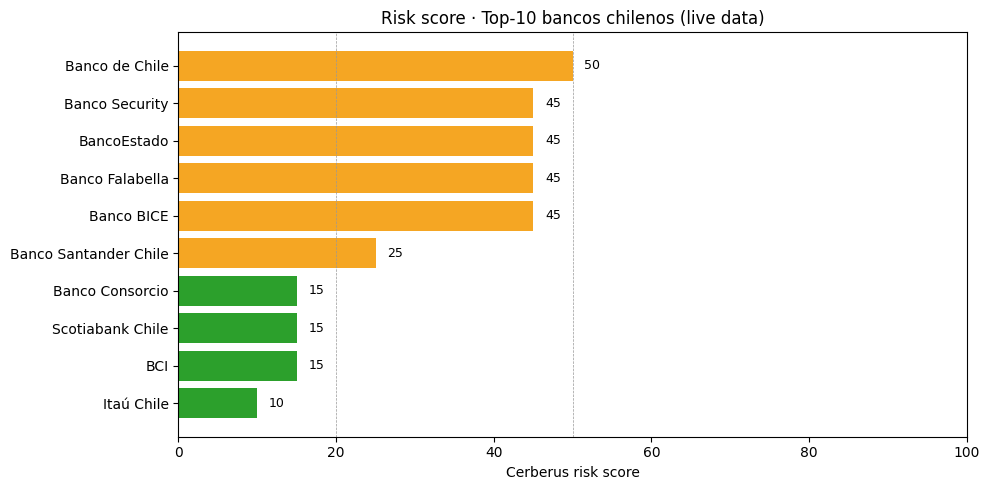

In [4]:
def _risk_color(s):
    if s is None:
        return "#999"
    if s <= 20:
        return "#2ca02c"
    if s <= 50:
        return "#f5a623"
    return "#d62728"


ordered = df.sort_values("risk_score")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(
    ordered["hint"], ordered["risk_score"], color=[_risk_color(s) for s in ordered["risk_score"]]
)
for b, s in zip(bars, ordered["risk_score"], strict=False):
    ax.text(s + 1.5, b.get_y() + b.get_height() / 2, f"{s}", va="center", fontsize=9)
ax.axvline(20, color="#999", lw=0.5, ls="--")
ax.axvline(50, color="#999", lw=0.5, ls="--")
ax.set_xlim(0, 100)
ax.set_xlabel("Cerberus risk score")
ax.set_title("Risk score · Top-10 bancos chilenos (live data)")
plt.tight_layout()
plt.show()

## 5 · Estado regulatorio: status, antigüedad y vigencia

Tres dimensiones críticas que el SDK expone en `kyb.get`:

- **`status`**: `vigente` / `no_vigente` / `disuelta`
- **`inscription_date`**: fecha de inscripción en CMF
- **`cancellation_date`**: fecha de cese (null si vigente)

> ⚠️ **Hallazgo de cobertura**: solo **1/10 banco** tiene
> `inscription_date` materializado (Banco de Chile, 1893-10-27 — 132
> años). El `cmf_universe_snapshot` ingestor del backend no ha
> completado para los demás RUTs. Validamos que esto NO es un staleness
> del endpoint `kyb.get`: el campo también está vacío vía
> `entities.by_rut` (mismo origen DB).

**Insight rescatado**: Banco Security aparece como `status='no_vigente'` —
señal regulatoria que ningún consumidor del SDK debería pasar por alto
(implica que la entidad está disuelta/fusionada y los datos históricos
son point-in-time).


In [5]:
# Status snapshot
status_summary = df["status"].value_counts()
print("Distribución de status:")
for s, n in status_summary.items():
    print(f"  {s:15s}  {n}")

print(
    f"\nBancos con status='no_vigente': "
    f"{', '.join(df[df['status'] == 'no_vigente']['hint'].tolist()) or 'ninguno'}"
)

print(
    f"\nCobertura inscription_date: "
    f"{df['inscription_date'].notna().sum()}/10 ({df['inscription_date'].notna().mean() * 100:.0f}%)"
)
print(f"Cobertura cancellation_date: {df['cancellation_date'].notna().sum()}/10")
print(f"\nBancos CON inscription_date:")
for _, row in df[df["inscription_date"].notna()].iterrows():
    print(f"  {row['hint']:25s}  {row['inscription_date'].date()}  ({row['age_years']:.0f} años)")

Distribución de status:
  vigente          9
  no_vigente       1

Bancos con status='no_vigente': Banco Security

Cobertura inscription_date: 1/10 (10%)
Cobertura cancellation_date: 0/10

Bancos CON inscription_date:
  Banco de Chile             1893-10-27  (132 años)


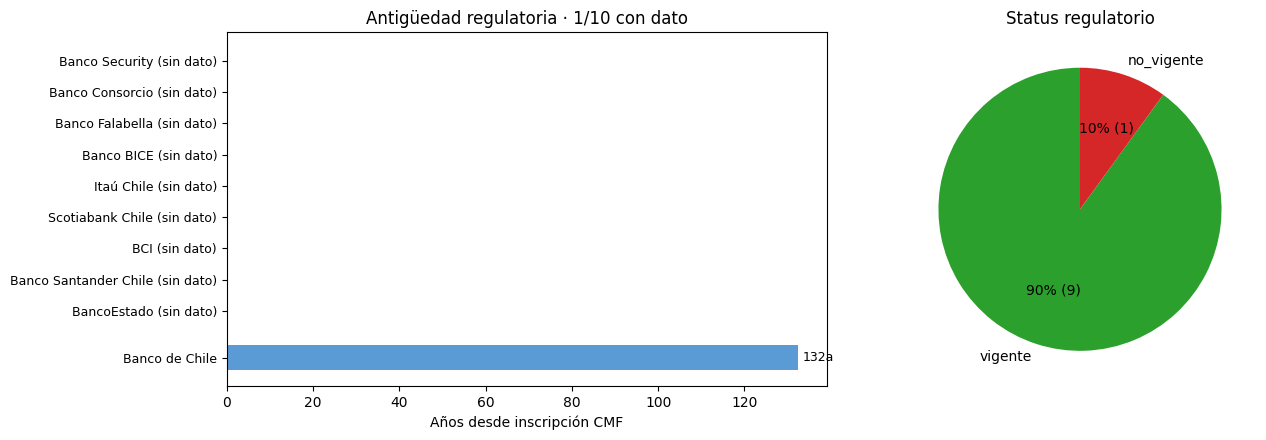

In [6]:
# Visualización: dos sub-paneles — antigüedad disponible + status
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Antigüedad — solo bancos con dato; los demás se muestran como gap
df_age = df[df["age_years"].notna()].sort_values("age_years")
df_gap = df[df["age_years"].isna()]
y_pos = list(range(len(df_age))) + [len(df_age) + 0.5 + i for i in range(len(df_gap))]
labels = list(df_age["hint"]) + [f"{h} (sin dato)" for h in df_gap["hint"]]
values = list(df_age["age_years"]) + [0] * len(df_gap)
colors = ["#5b9bd5"] * len(df_age) + ["#dddddd"] * len(df_gap)

axes[0].barh(y_pos, values, color=colors)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(labels, fontsize=9)
for i, v in enumerate(df_age["age_years"]):
    axes[0].text(v + 1, i, f"{v:.0f}a", va="center", fontsize=9)
axes[0].set_xlabel("Años desde inscripción CMF")
axes[0].set_title(f"Antigüedad regulatoria · {len(df_age)}/10 con dato")

# (b) Status pie
status_counts = df["status"].value_counts()
status_colors = {"vigente": "#2ca02c", "no_vigente": "#d62728", "disuelta": "#999"}
axes[1].pie(
    status_counts.values,
    labels=status_counts.index,
    colors=[status_colors.get(s, "#bbb") for s in status_counts.index],
    autopct=lambda p: f"{p:.0f}% ({int(p * sum(status_counts) / 100)})",
    startangle=90,
)
axes[1].set_title("Status regulatorio")

plt.tight_layout()
plt.show()

## 6 · LEI + grafo de ownership GLEIF Level-2

El SDK expone tres fuentes de LEI:

| Fuente | Fiabilidad |
|---|---|
| `entities.by_rut(rut).lei` | ✅ canónica — refleja el último GLEIF refresh |
| `entities.ownership(id).subject_lei` | ✅ canónica — mismo backing store |
| `kyb.get(rut).lei` | ⚠️ **stale** — solo refleja LEIs que existían antes del último cache flush del endpoint `/kyb` |

**Por eso este notebook usa `entity.lei` / `ownership.subject_lei`** como
source-of-truth en lugar de `kyb.lei`, evitando el sesgo de la celda §3.


In [7]:
async def fetch_entity_and_ownership(c, item):
    rut, hint = item
    try:
        ent = await c.entities.by_rut(rut)
        own = await c.entities.ownership(ent["id"])
        return {
            "hint": hint,
            "rut": rut,
            "entity_id": ent["id"],
            "entity_lei": ent.get("lei"),
            "ownership": own,
            "entity": ent,
        }
    except Exception as e:
        return {
            "hint": hint,
            "rut": rut,
            "entity_id": None,
            "entity_lei": None,
            "ownership": {},
            "entity": {},
            "err": str(e)[:100],
        }


ownerships = asyncio.run(gather_throttled(fetch_entity_and_ownership, BANKS, concurrency=5))

# Tabla LEI · 3 fuentes lado a lado
lei_rows = []
for o in ownerships:
    own = o.get("ownership") or {}
    subj = own.get("subject_lei")
    if isinstance(subj, dict):
        subj = subj.get("lei")
    profile = next(p for p in profiles if p["rut"] == o["rut"])
    lei_rows.append(
        {
            "banco": o["hint"],
            "kyb.get.lei": profile.get("lei") or "—",
            "entity.lei": o.get("entity_lei") or "—",
            "ownership.subject_lei": subj or "—",
            "direct_parent": "✓" if own.get("direct_parent") else "—",
            "ultimate_parent": "✓" if own.get("ultimate_parent") else "—",
        }
    )
df_own = pd.DataFrame(lei_rows)
df_own

,banco,kyb.get.lei,entity.lei,ownership.subject_lei,direct_parent,ultimate_parent
0,BancoEstado,—,5493004R4EJC0W0XVQ72,5493004R4EJC0W0XVQ72,—,—
1,Banco de Chile,PVVK4N5A7MITLWQJQQ35,PVVK4N5A7MITLWQJQQ35,PVVK4N5A7MITLWQJQQ35,—,—
2,Banco Santander Chile,—,3YJP8HORPAEXJ80D6368,3YJP8HORPAEXJ80D6368,—,—
3,BCI,—,549300E9E5Y3PKW24142,549300E9E5Y3PKW24142,—,—
4,Scotiabank Chile,—,54930018SOOHBHRLWC16,54930018SOOHBHRLWC16,—,—
5,Itaú Chile,549300DDPTTIZ06NIV06,549300DDPTTIZ06NIV06,549300DDPTTIZ06NIV06,—,—
6,Banco BICE,—,549300GZLN4QH0YBEL90,549300GZLN4QH0YBEL90,—,—
7,Banco Falabella,—,549300JGIJIWD1F37S39,549300JGIJIWD1F37S39,—,—
8,Banco Consorcio,—,549300HONNZES9JKE471,549300HONNZES9JKE471,—,—
9,Banco Security,—,549300QPI6J16OMO1120,549300QPI6J16OMO1120,—,—


### 6a · Detección de discrepancias entre endpoints

Si `kyb.lei != entity.lei`, el endpoint `/kyb/{rut}` está sirviendo
un valor stale. Esto es información valiosa para el equipo backend.


In [8]:
# Compute discrepancies
discrepancies = []
for o in ownerships:
    profile = next(p for p in profiles if p["rut"] == o["rut"])
    kyb_lei = profile.get("lei")
    ent_lei = o.get("entity_lei")
    if (kyb_lei or "") != (ent_lei or ""):
        discrepancies.append(
            {
                "banco": o["hint"],
                "kyb.get.lei": kyb_lei or "(null)",
                "entity.lei": ent_lei or "(null)",
                "veredicto": "kyb endpoint está stale"
                if not kyb_lei
                else "kyb tiene valor distinto",
            }
        )

if discrepancies:
    print(f"⚠️  Detectadas {len(discrepancies)} discrepancias kyb.lei vs entity.lei:")
    for d in discrepancies:
        print(
            f"  {d['banco']:25s} kyb={d['kyb.get.lei']:22s} entity={d['entity.lei']:22s} → {d['veredicto']}"
        )
    print("\n→ Acción recomendada al backend: revisar el join de LEI en /kyb/{rut}.")
    print("  El campo `lei` debería materializarse desde `cmf_entities.lei` (la misma")
    print("  columna que ya consume /entities/by-rut/{rut}).")
else:
    print("✓ No se detectaron discrepancias — kyb.lei == entity.lei en todos los bancos.")

⚠️  Detectadas 8 discrepancias kyb.lei vs entity.lei:
  BancoEstado               kyb=(null)                 entity=5493004R4EJC0W0XVQ72   → kyb endpoint está stale
  Banco Santander Chile     kyb=(null)                 entity=3YJP8HORPAEXJ80D6368   → kyb endpoint está stale
  BCI                       kyb=(null)                 entity=549300E9E5Y3PKW24142   → kyb endpoint está stale
  Scotiabank Chile          kyb=(null)                 entity=54930018SOOHBHRLWC16   → kyb endpoint está stale
  Banco BICE                kyb=(null)                 entity=549300GZLN4QH0YBEL90   → kyb endpoint está stale
  Banco Falabella           kyb=(null)                 entity=549300JGIJIWD1F37S39   → kyb endpoint está stale
  Banco Consorcio           kyb=(null)                 entity=549300HONNZES9JKE471   → kyb endpoint está stale
  Banco Security            kyb=(null)                 entity=549300QPI6J16OMO1120   → kyb endpoint está stale

→ Acción recomendada al backend: revisar el join de LEI e

### 6b · Cobertura LEI corregida (usando la fuente canónica)

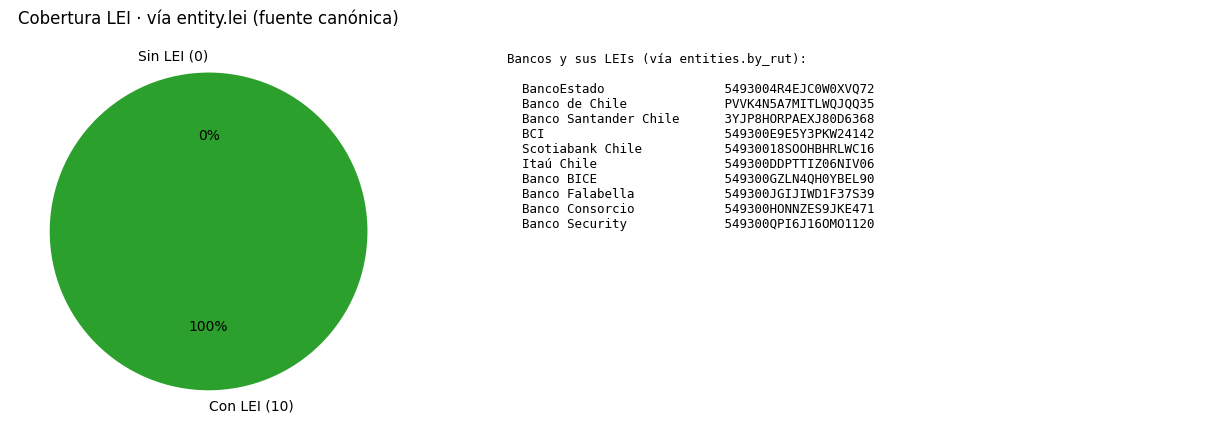

In [9]:
# Cobertura usando la fuente canónica (entity.lei)
df["entity_lei"] = df["rut"].map({o["rut"]: o.get("entity_lei") for o in ownerships})
df["has_lei"] = df["entity_lei"].notna()
n_with_lei = df["has_lei"].sum()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Pie: cobertura
axes[0].pie(
    [n_with_lei, 10 - n_with_lei],
    labels=[f"Con LEI ({n_with_lei})", f"Sin LEI ({10 - n_with_lei})"],
    colors=["#2ca02c", "#bbbbbb"],
    autopct=lambda p: f"{p:.0f}%",
    startangle=90,
)
axes[0].set_title("Cobertura LEI · vía entity.lei (fuente canónica)")

# Tabla visual
axes[1].axis("off")
listing = "Bancos y sus LEIs (vía entities.by_rut):\n\n"
for _, row in df.iterrows():
    lei = row["entity_lei"] or "—"
    listing += f"  {row['hint']:25s}  {lei}\n"
axes[1].text(
    0.0,
    0.95,
    listing,
    va="top",
    ha="left",
    family="monospace",
    fontsize=9,
    transform=axes[1].transAxes,
)

plt.tight_layout()
plt.show()

## 7 · Composición de directorios

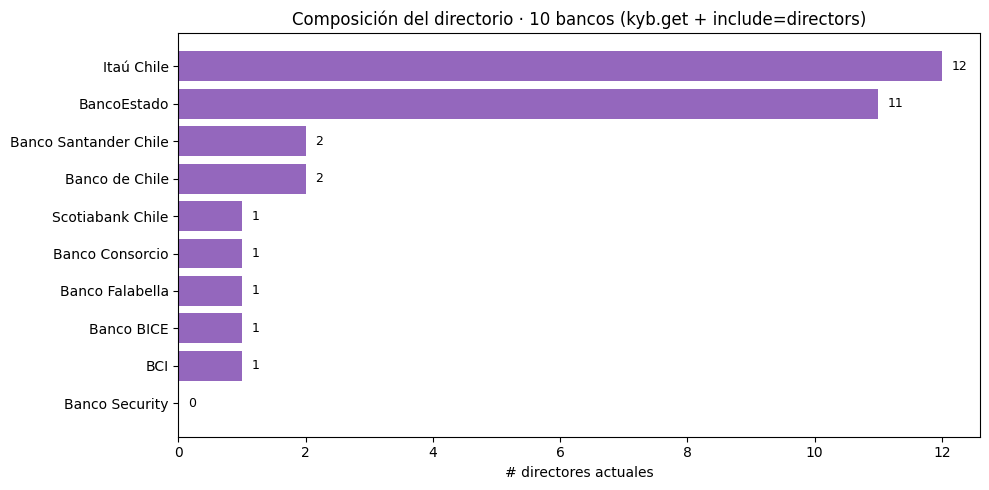

Total directores listados: 32

Distribución de cargos:
cargo
director           21
gerente_general     8
presidente          3


In [10]:
ordered3 = df.sort_values("n_directors")
fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(ordered3["hint"], ordered3["n_directors"], color="#9467bd")
for b, n in zip(bars, ordered3["n_directors"], strict=False):
    ax.text(n + 0.15, b.get_y() + b.get_height() / 2, f"{n}", va="center", fontsize=9)
ax.set_xlabel("# directores actuales")
ax.set_title("Composición del directorio · 10 bancos (kyb.get + include=directors)")
plt.tight_layout()
plt.show()

all_dirs = []
for p in profiles:
    for d in p["_directors"]:
        all_dirs.append(
            {
                "banco": p["hint"],
                "cargo": d.get("cargo"),
                "nombre": d.get("nombre"),
                "rut": d.get("persona_rut"),
                "fecha_inicio": d.get("fecha_inicio"),
            }
        )
df_dirs = pd.DataFrame(all_dirs)
print(f"Total directores listados: {len(df_dirs)}")
if len(df_dirs):
    print("\nDistribución de cargos:")
    print(df_dirs["cargo"].value_counts().head(10).to_string())

## 8 · Análisis de cruce de directores entre bancos

Si una persona ocupa cargos en >1 banco, hay un riesgo potencial de
**conflicto de interés** o **influencia cross-empresa**. Buscamos RUTs
de personas que aparecen en múltiples bancos del portfolio.

> El backend solo trae 1-12 directores por banco (gap de ingestión
> del `cmf_directores_gerentes` ingestor) — la muestra es chica, así
> que los hallazgos son indicativos, no exhaustivos.


In [11]:
# Multi-bank directors
person_to_posts: dict[str, list] = {}
for d in all_dirs:
    rut = d["rut"]
    if rut:
        person_to_posts.setdefault(rut, []).append(d)

multi = {
    rut: posts for rut, posts in person_to_posts.items() if len({p["banco"] for p in posts}) > 1
}
print(f"Personas únicas en directorios: {len(person_to_posts)}")
print(f"Personas con cargos en >1 banco distinto: {len(multi)}")
if multi:
    for rut, posts in multi.items():
        nombre = posts[0]["nombre"]
        bancos = sorted({p["banco"] for p in posts})
        print(f"  {rut}  {nombre}: {bancos}")
else:
    print("  → No se detectaron cruces inter-banco en este sample.")

# Multi-cargo dentro del mismo banco
multi_cargo = {
    rut: posts
    for rut, posts in person_to_posts.items()
    if len({(p["banco"], p["cargo"]) for p in posts}) > 1 and len({p["banco"] for p in posts}) == 1
}
print(f"\nPersonas con múltiples cargos en el mismo banco: {len(multi_cargo)}")
for rut, posts in multi_cargo.items():
    nombre = posts[0]["nombre"]
    print(f"  {rut}  {nombre}  ({posts[0]['banco']}): {[p['cargo'] for p in posts]}")

Personas únicas en directorios: 31
Personas con cargos en >1 banco distinto: 0
  → No se detectaron cruces inter-banco en este sample.

Personas con múltiples cargos en el mismo banco: 1
  6.972.382-9  PABLO JOSÉ GRANIFO LAVIN  (Banco de Chile): ['presidente', 'director']


## 9 · Bancos · fichas regulatorias SBIF (cobertura por sección)

In [12]:
async def fetch_fichas(c, item):
    rut, hint = item
    try:
        body = await c.entities.bancos_fichas_latest_per_section(rut)
        return {"hint": hint, "rut": rut, "sections": body.get("sections", []), "ok": True}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sections": [], "ok": False, "err": str(e)[:120]}


fichas = asyncio.run(gather_throttled(fetch_fichas, BANKS, concurrency=5))

section_matrix = []
for f in fichas:
    sections = {
        s["section"]: f"FY{s.get('fiscal_year')}-M{s.get('fiscal_month'):02d}"
        for s in f["sections"]
        if s.get("fiscal_month")
    }
    section_matrix.append({"banco": f["hint"], **sections})
df_cov = pd.DataFrame(section_matrix).set_index("banco").fillna("—")
df_cov

,adecuacion_capital,integrantes,perfil,accionistas
banco,,,,
BancoEstado,FY2020-M11,FY2026-M04,FY2026-M04,—
Banco de Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Santander Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
BCI,FY2020-M10,FY2026-M04,FY2026-M04,FY2026-M04
Scotiabank Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Itaú Chile,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco BICE,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Falabella,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04
Banco Consorcio,FY2020-M11,FY2026-M04,FY2026-M04,FY2026-M04


## 10 · Footprint físico (sucursales · cajeros · empleados)

In [13]:
def _extract_perfil(f):
    for s in f.get("sections", []):
        if s["section"] == "perfil":
            perfiles = (s.get("payload") or {}).get("Perfiles") or []
            if perfiles:
                return perfiles[0].get("Perfil") or {}
    return {}


perfil_rows = []
for f in fichas:
    p = _extract_perfil(f)
    if p:
        perfil_rows.append(
            {
                "banco": f["hint"],
                "sucursales": p.get("sucursales") or 0,
                "oficinas": p.get("oficinas") or 0,
                "cajeros": p.get("cajeros") or 0,
                "empleados": p.get("empleados") or 0,
                "swift": p.get("codigoSWIFT") or "—",
                "web": p.get("direccionWeb") or "—",
            }
        )

df_perfil = pd.DataFrame(perfil_rows).sort_values("empleados", ascending=False)
print(f"Bancos con perfil físico disponible: {len(df_perfil)}/10\n")
print(df_perfil[["banco", "sucursales", "cajeros", "empleados", "swift"]].to_string(index=False))

Bancos con perfil físico disponible: 9/10

                banco  sucursales  cajeros  empleados      swift
          BancoEstado         426     2554      10711 BECH CL RM
       Banco de Chile         211     1881      10297 BCHI CL RM
Banco Santander Chile         158     2064       8002 BSCH CL RM
                  BCI         168      548       7439 CRED CL RM
     Scotiabank Chile          92      153       5118 BKSA CL RM
           Itaú Chile          94      140       4484   ITAUCLRM
           Banco BICE          40       36       2854 BICE CL RM
      Banco Falabella          71      366       2071 FALA CL RM
      Banco Consorcio          16       12       1064 MNEX CL RM


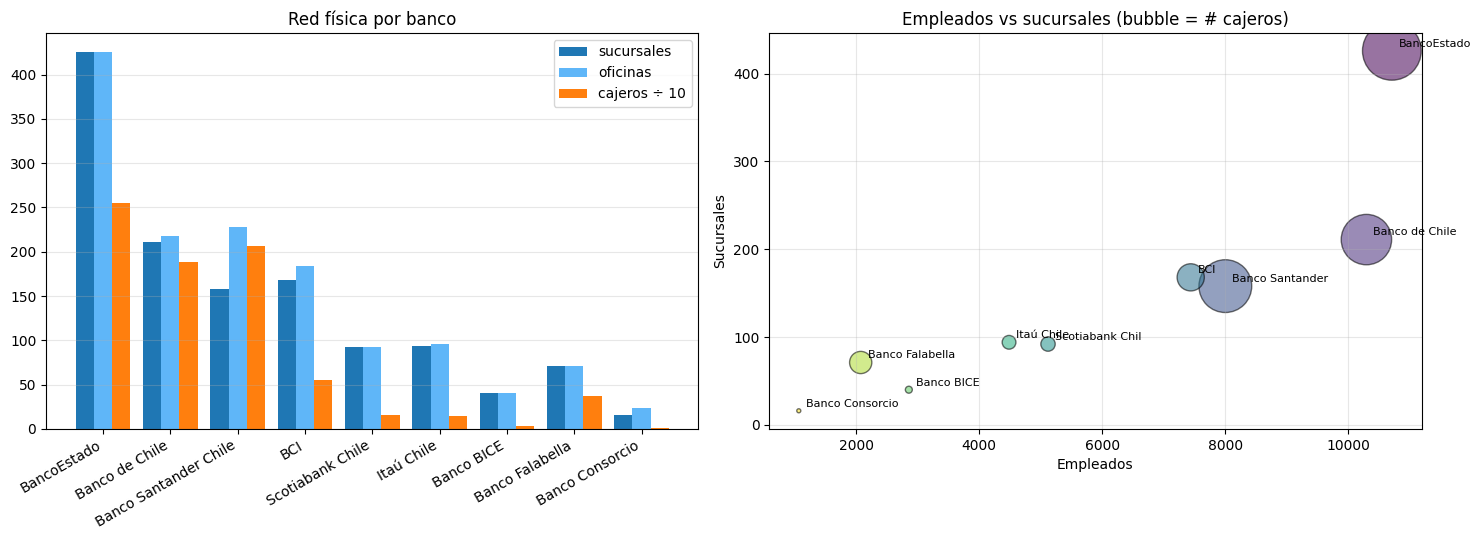

In [14]:
if len(df_perfil) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
    ax = axes[0]
    x = list(range(len(df_perfil)))
    width = 0.27
    ax.bar(
        [i - width for i in x], df_perfil["sucursales"], width, label="sucursales", color="#1f77b4"
    )
    ax.bar(x, df_perfil["oficinas"], width, label="oficinas", color="#5fb6f8")
    ax.bar(
        [i + width for i in x],
        df_perfil["cajeros"] / 10,
        width,
        label="cajeros ÷ 10",
        color="#ff7f0e",
    )
    ax.set_xticks(x)
    ax.set_xticklabels(df_perfil["banco"], rotation=30, ha="right")
    ax.set_title("Red física por banco")
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

    ax = axes[1]
    sizes = df_perfil["cajeros"].fillna(0).clip(lower=10) * 0.7
    ax.scatter(
        df_perfil["empleados"],
        df_perfil["sucursales"],
        s=sizes,
        alpha=0.55,
        c=range(len(df_perfil)),
        cmap="viridis",
        edgecolor="black",
    )
    for _, row in df_perfil.iterrows():
        ax.annotate(
            row["banco"][:15],
            (row["empleados"], row["sucursales"]),
            fontsize=8,
            xytext=(5, 3),
            textcoords="offset points",
        )
    ax.set_xlabel("Empleados")
    ax.set_ylabel("Sucursales")
    ax.set_title("Empleados vs sucursales (bubble = # cajeros)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 11 · Adecuación de capital (Basel III) — Tier 1 + Total ratio

In [15]:
def _to_float(s):
    if s is None or s == "":
        return None
    if isinstance(s, (int, float)):
        return float(s)
    return float(str(s).replace(".", "").replace(",", "."))


def _extract_capital(f):
    for s in f.get("sections", []):
        if s["section"] == "adecuacion_capital":
            arr = (s.get("payload") or {}).get("AdecuacionDeCapital") or []
            if arr:
                comp = arr[0].get("Componentes") or {}
                act = comp.get("Activos") or {}
                pat = comp.get("PatrimonioEfectivo") or {}
                return {
                    "as_of": f"{s.get('fiscal_year')}-{s.get('fiscal_month'):02d}",
                    "activos_totales": _to_float(act.get("Totales")),
                    "rwa": _to_float(act.get("PonderadosPorRiesgo")),
                    "patrimonio_total": _to_float(pat.get("Total")),
                    "capital_basico": _to_float(pat.get("CapitalBasico")),
                    "bonos_subordinados": _to_float(pat.get("BonosSubordinados")),
                }
    return None


cap_rows = []
for f in fichas:
    cap = _extract_capital(f)
    if cap:
        cap["banco"] = f["hint"]
        cap["tier1_pct"] = (cap["capital_basico"] / cap["rwa"] * 100) if cap["rwa"] else None
        cap["total_pct"] = (cap["patrimonio_total"] / cap["rwa"] * 100) if cap["rwa"] else None
        cap_rows.append(cap)

df_cap = pd.DataFrame(cap_rows).sort_values("total_pct", ascending=True)
print(f"Bancos con adecuación de capital: {len(df_cap)}/10")
df_cap[
    [
        "banco",
        "as_of",
        "activos_totales",
        "rwa",
        "capital_basico",
        "patrimonio_total",
        "tier1_pct",
        "total_pct",
    ]
]

Bancos con adecuación de capital: 9/10


,banco,as_of,activos_totales,rwa,capital_basico,patrimonio_total,tier1_pct,total_pct
0,BancoEstado,2020-11,4.974778e+07,2.493909e+07,2.012257e+06,3.158270e+06,8.068686,12.663933
4,Scotiabank Chile,2020-11,3.521686e+07,2.483721e+07,2.377898e+06,3.195704e+06,9.573932,12.866597
3,BCI,2020-10,5.700937e+07,3.861257e+07,3.938828e+06,4.982904e+06,10.200895,12.904873
5,Itaú Chile,2020-11,3.590571e+07,2.343724e+07,2.358248e+06,3.104306e+06,10.061970,13.245184
6,Banco BICE,2020-11,9.597613e+06,6.729136e+06,6.495415e+05,8.960638e+05,9.652673,13.316179
2,Banco Santander Chile,2020-11,5.266018e+07,3.437209e+07,3.489817e+06,5.037503e+06,10.153054,14.655796
1,Banco de Chile,2020-11,4.748534e+07,3.110592e+07,3.722925e+06,4.854002e+06,11.968542,15.604755
8,Banco Consorcio,2020-11,6.242243e+06,4.675667e+06,5.810867e+05,8.263901e+05,12.427888,17.674273
7,Banco Falabella,2020-11,6.312691e+06,4.280707e+06,6.358385e+05,8.222708e+05,14.853588,19.208763


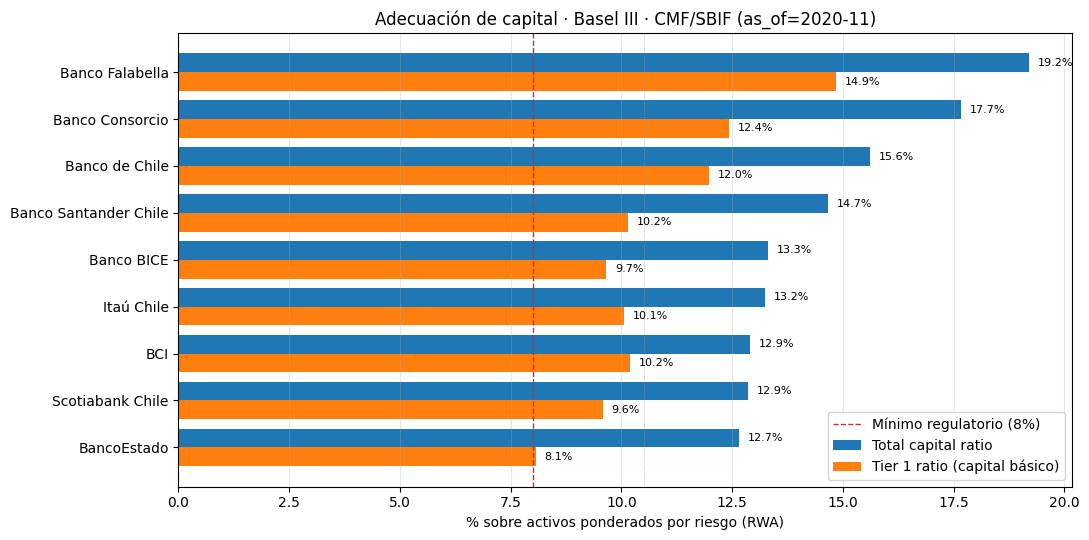


Tier 1 promedio: 10.77%
Total capital ratio promedio: 14.68%


In [16]:
if len(df_cap) >= 3:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    y = list(range(len(df_cap)))
    ax.barh(
        [i + 0.2 for i in y], df_cap["total_pct"], 0.4, label="Total capital ratio", color="#1f77b4"
    )
    ax.barh(
        [i - 0.2 for i in y],
        df_cap["tier1_pct"],
        0.4,
        label="Tier 1 ratio (capital básico)",
        color="#ff7f0e",
    )
    for i, (t1, tot) in enumerate(zip(df_cap["tier1_pct"], df_cap["total_pct"], strict=False)):
        ax.text(tot + 0.2, i + 0.2, f"{tot:.1f}%", va="center", fontsize=8)
        ax.text(t1 + 0.2, i - 0.2, f"{t1:.1f}%", va="center", fontsize=8)
    ax.axvline(8.0, color="#d62728", lw=1, ls="--", label="Mínimo regulatorio (8%)")
    ax.axvline(10.5, color="#999", lw=0.5, ls=":")
    ax.set_yticks(y)
    ax.set_yticklabels(df_cap["banco"])
    ax.set_xlabel("% sobre activos ponderados por riesgo (RWA)")
    ax.set_title(
        f"Adecuación de capital · Basel III · CMF/SBIF (as_of={df_cap['as_of'].mode().iloc[0]})"
    )
    ax.legend()
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"\nTier 1 promedio: {df_cap['tier1_pct'].mean():.2f}%")
    print(f"Total capital ratio promedio: {df_cap['total_pct'].mean():.2f}%")

## 12 · Top accionistas — concentración de propiedad

In [17]:
_AGGREGATOR_NAMES = {
    "TOTAL",
    "SUBTOTAL",
    "12 ACCIONISTAS MAYORITARIOS",
    "RESTO ACCIONISTAS",
    "OTROS ACCIONISTAS",
}


def _is_aggregator(name: str) -> bool:
    n = (name or "").strip().upper()
    if not n:
        return True
    if n in _AGGREGATOR_NAMES:
        return True
    if n.startswith(("OTROS ", "RESTO ")):
        return True
    return bool("ACCIONISTAS" in n and ("MAYORIT" in n or "MINORIT" in n))


def _extract_accionistas(f, top=5):
    for s in f.get("sections", []):
        if s["section"] == "accionistas":
            arr = (s.get("payload") or {}).get("Accionistas") or []
            rows = []
            for a in arr:
                d = a.get("DescripcionAccionista") or {}
                nombre = d.get("Nombre", "")
                if _is_aggregator(nombre):
                    continue
                rows.append(
                    {
                        "rut": d.get("Rut"),
                        "nombre": nombre,
                        "participacion": float(d.get("Participacion") or 0),
                        "n_acciones": int(d.get("NumeroAcciones") or 0),
                    }
                )
            rows.sort(key=lambda r: r["participacion"], reverse=True)
            return rows[:top]
    return []


# También extraemos TODOS los accionistas (no solo top-5) para HHI
def _extract_accionistas_all(f):
    for s in f.get("sections", []):
        if s["section"] == "accionistas":
            arr = (s.get("payload") or {}).get("Accionistas") or []
            rows = []
            for a in arr:
                d = a.get("DescripcionAccionista") or {}
                nombre = d.get("Nombre", "")
                if _is_aggregator(nombre):
                    continue
                rows.append({"nombre": nombre, "participacion": float(d.get("Participacion") or 0)})
            return rows
    return []


acc_rows = []
for f in fichas:
    for a in _extract_accionistas(f, top=5):
        acc_rows.append({"banco": f["hint"], **a})

df_acc = pd.DataFrame(acc_rows)
print(f"Bancos con accionistas en ficha: {df_acc['banco'].nunique() if len(df_acc) else 0}/10")
print(f"\nTop accionista por banco:")
top1 = df_acc.sort_values("participacion", ascending=False).drop_duplicates("banco")
for _, r in top1.sort_values("participacion", ascending=False).iterrows():
    print(f"  {r['banco']:25s}  {r['nombre'][:42]:42s}  {r['participacion']:>6.2f}%")

Bancos con accionistas en ficha: 8/10

Top accionista por banco:
  Banco Falabella            FALABELLA INV FINANCIERAS S.A.              100.00%
  Banco Consorcio            CONSOR FINANCIERO S.A.                       99.99%
  Banco BICE                 BICECORP S.A.                                99.94%
  Scotiabank Chile           NOVA SCOTIA INV LTDA                         99.80%
  BCI                        EMP JUAN YARUR S.A.C.                        55.36%
  Banco de Chile             LQ INV FINANCIERAS S.A.                      46.34%
  Itaú Chile                 ITB HOLDING BRASIL PARTICIPACOES             36.42%
  Banco Santander Chile      SANTANDER CHILE HOLDING S.A.                 35.46%


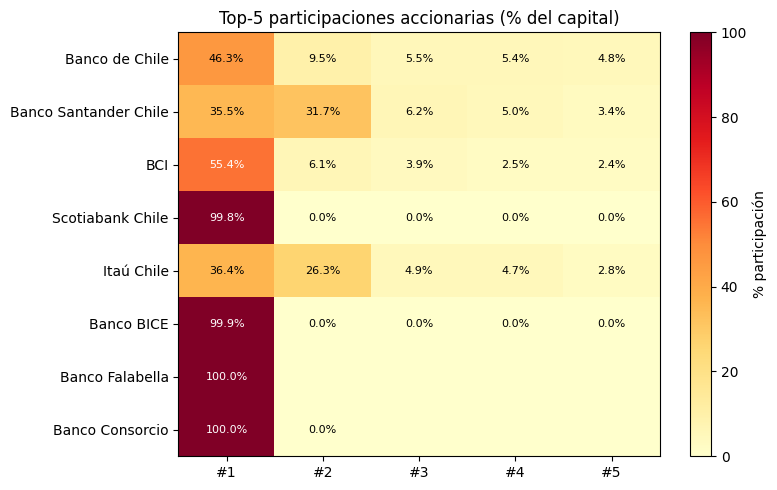

In [18]:
if len(df_acc) >= 3:
    banks_with_acc = df_acc["banco"].unique()
    heat_rows = []
    for b in banks_with_acc:
        top5 = df_acc[df_acc["banco"] == b].nlargest(5, "participacion")["participacion"].tolist()
        while len(top5) < 5:
            top5.append(0)
        heat_rows.append((b, top5))
    heat = pd.DataFrame(
        [r[1] for r in heat_rows],
        index=[r[0] for r in heat_rows],
        columns=[f"#{i}" for i in range(1, 6)],
    )

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(heat) + 1)))
    im = ax.imshow(heat.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=heat.values.max())
    ax.set_xticks(range(5))
    ax.set_xticklabels(heat.columns)
    ax.set_yticks(range(len(heat)))
    ax.set_yticklabels(heat.index)
    for i in range(len(heat)):
        for j in range(5):
            v = heat.iloc[i, j]
            if v > 0:
                ax.text(
                    j,
                    i,
                    f"{v:.1f}%",
                    ha="center",
                    va="center",
                    color="white" if v > heat.values.max() * 0.5 else "black",
                    fontsize=8,
                )
    ax.set_title("Top-5 participaciones accionarias (% del capital)")
    fig.colorbar(im, ax=ax, label="% participación")
    plt.tight_layout()
    plt.show()

## 13 · Concentración accionaria · índice HHI Herfindahl-Hirschman

HHI = Σ(participación_i)² · escala 0–10000:

- **HHI > 2500** → mercado / propiedad **altamente concentrado**
- **HHI 1500–2500** → moderadamente concentrado
- **HHI < 1500** → no concentrado

En el contexto bancario, un HHI alto significa **propiedad casi
monolítica** (un único holding o accionista controla); HHI bajo
significa propiedad atomizada.


In [19]:
hhi_rows = []
for f in fichas:
    accs = _extract_accionistas_all(f)
    if not accs:
        continue
    hhi = sum((a["participacion"]) ** 2 for a in accs)
    top1 = max(a["participacion"] for a in accs)
    n_signif = sum(1 for a in accs if a["participacion"] >= 1.0)
    hhi_rows.append(
        {
            "banco": f["hint"],
            "n_accionistas_listados": len(accs),
            "n_accionistas_>=1pct": n_signif,
            "top1_pct": round(top1, 2),
            "hhi": round(hhi, 0),
        }
    )

df_hhi = pd.DataFrame(hhi_rows).sort_values("hhi", ascending=False)
print("Concentración accionaria (HHI — más alto = más concentrado):")
print(df_hhi.to_string(index=False))

Concentración accionaria (HHI — más alto = más concentrado):
                banco  n_accionistas_listados  n_accionistas_>=1pct  top1_pct     hhi
      Banco Falabella                       2                     1    100.00 10000.0
      Banco Consorcio                       2                     1     99.99  9998.0
           Banco BICE                      15                     1     99.94  9988.0
     Scotiabank Chile                      15                     1     99.80  9959.0
                  BCI                      15                    14     55.36  3155.0
Banco Santander Chile                      15                     9     35.46  2359.0
       Banco de Chile                      15                    12     46.34  2341.0
           Itaú Chile                      15                    11     36.42  2096.0


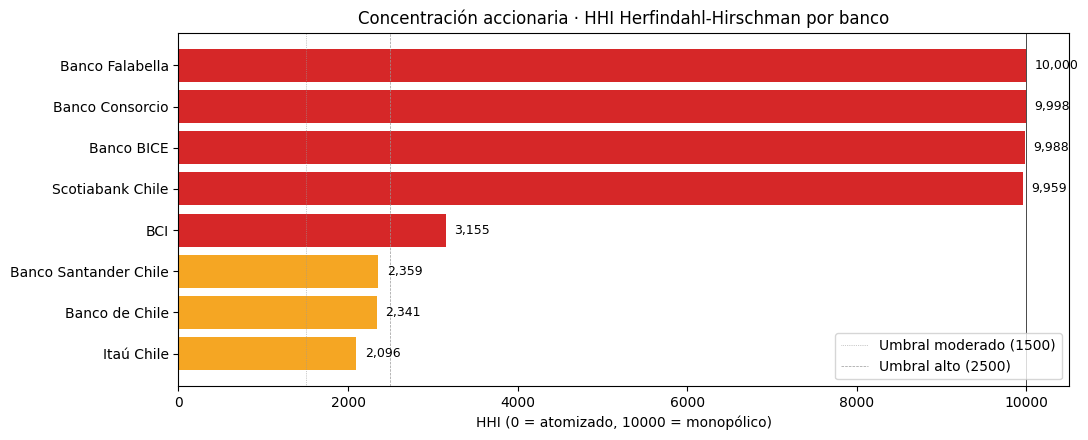

In [20]:
if len(df_hhi):
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ordered_h = df_hhi.sort_values("hhi")
    colors = [
        "#d62728" if h >= 2500 else "#f5a623" if h >= 1500 else "#2ca02c" for h in ordered_h["hhi"]
    ]
    ax.barh(ordered_h["banco"], ordered_h["hhi"], color=colors)
    for i, h in enumerate(ordered_h["hhi"]):
        ax.text(h + 100, i, f"{int(h):,}", va="center", fontsize=9)
    ax.axvline(1500, color="#999", lw=0.5, ls=":", label="Umbral moderado (1500)")
    ax.axvline(2500, color="#999", lw=0.5, ls="--", label="Umbral alto (2500)")
    ax.axvline(10000, color="#000", lw=0.5, ls="-")
    ax.set_xlabel("HHI (0 = atomizado, 10000 = monopólico)")
    ax.set_title("Concentración accionaria · HHI Herfindahl-Hirschman por banco")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 14 · Sanciones CMF · análisis profundo

Pulleamos las sanciones detalladas por banco vía
`entities.sanctions(entity_id)` y construimos múltiples vistas: counts,
estado distribution, timeline, día desde última, palabras frecuentes en
el campo `infraccion`.


In [21]:
async def fetch_sanctions(c, item):
    rut, hint = item
    try:
        ent = await c.entities.by_rut(rut)
        eid = ent["id"]
        sancs = await c.entities.sanctions(eid)
        return {"hint": hint, "rut": rut, "entity_id": eid, "sanctions": sancs}
    except Exception as e:
        return {"hint": hint, "rut": rut, "sanctions": [], "err": str(e)[:120]}


bank_sancs = asyncio.run(gather_throttled(fetch_sanctions, BANKS, concurrency=5))

sanc_rows = []
for bs in bank_sancs:
    for s in bs["sanctions"]:
        sanc_rows.append(
            {
                "banco": bs["hint"],
                "id": s.get("cmf_resolucion_id"),
                "fecha": s.get("fecha_resolucion"),
                "estado": s.get("estado"),
                "multa_uf": s.get("multa_uf"),
                "multa_clp": s.get("multa_clp"),
                "persona_natural": s.get("persona_natural_nombre"),
                "infraccion": s.get("infraccion") or "",
            }
        )
df_sanc = pd.DataFrame(sanc_rows)
df_sanc["fecha"] = pd.to_datetime(df_sanc["fecha"], errors="coerce")
df_sanc["multa_uf_num"] = pd.to_numeric(df_sanc["multa_uf"], errors="coerce")
df_sanc["multa_clp_num"] = pd.to_numeric(df_sanc["multa_clp"], errors="coerce")
df_sanc["año"] = df_sanc["fecha"].dt.year

print(f"Total sanciones: {len(df_sanc)}")
print(f"Rango: {df_sanc['fecha'].min().date()} → {df_sanc['fecha'].max().date()}")
print(f"\nDistribución de estado:")
print(df_sanc["estado"].value_counts().to_string())
print(f"\nMultas registradas:")
print(f"  con multa_uf : {df_sanc['multa_uf_num'].notna().sum()}/{len(df_sanc)}")
print(f"  con multa_clp: {df_sanc['multa_clp_num'].notna().sum()}/{len(df_sanc)}")
print(f"  ⚠️  el ingestor cmf_sanciones extrae fechas e infracciones bien,")
print(f"     pero el regex de monto está fallando para la mayoría — ")
print(f"     gap conocido del backend. Las que sí tienen multa:")
for _, r in df_sanc[df_sanc["multa_uf_num"].notna()].iterrows():
    print(
        f"     · {r['banco']:23s} {r['fecha'].date()}  {r['multa_uf_num']:>8.2f} UF · {r['estado']}"
    )

Total sanciones: 43
Rango: 2020-05-28 → 2026-02-09

Distribución de estado:
estado
prescrita    39
vigente       4

Multas registradas:
  con multa_uf : 1/43
  con multa_clp: 0/43
  ⚠️  el ingestor cmf_sanciones extrae fechas e infracciones bien,
     pero el regex de monto está fallando para la mayoría — 
     gap conocido del backend. Las que sí tienen multa:
     · Banco BICE              2020-05-28    398.05 UF · vigente


### 14a · Sanciones por banco · count + distribución de estado

In [22]:
# Aggregate per banco
agg = (
    df_sanc.groupby("banco")
    .size()
    .reindex([h for _, h in BANKS])
    .fillna(0)
    .astype(int)
    .rename("n")
    .reset_index()
)
estado_pivot = (
    df_sanc.groupby(["banco", "estado"])
    .size()
    .unstack(fill_value=0)
    .reindex([h for _, h in BANKS])
    .fillna(0)
    .astype(int)
)
estado_pivot["total"] = estado_pivot.sum(axis=1)
estado_pivot = estado_pivot.sort_values("total")
estado_pivot

estado,prescrita,vigente,total
banco,,,
Banco BICE,1,1,2
Banco Security,3,0,3
Scotiabank Chile,4,0,4
Banco de Chile,3,1,4
Itaú Chile,4,0,4
BCI,4,0,4
Banco Consorcio,4,0,4
Banco Falabella,4,1,5
BancoEstado,5,1,6


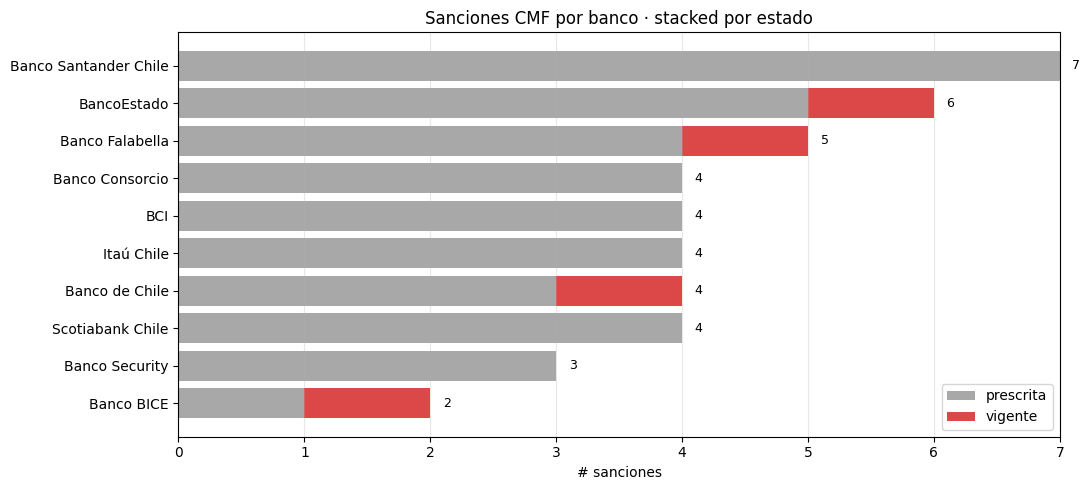

In [23]:
# Stacked bar — count por banco, segmentado por estado
fig, ax = plt.subplots(figsize=(11, 5))
estados = [c for c in estado_pivot.columns if c != "total"]
estado_colors = {
    "prescrita": "#999",
    "vigente": "#d62728",
    "firme": "#1f77b4",
    "extinguida": "#2ca02c",
    "anulada": "#9467bd",
}
left = pd.Series(0, index=estado_pivot.index)
for est in estados:
    color = estado_colors.get(est, "#bbb")
    ax.barh(estado_pivot.index, estado_pivot[est], left=left, label=est, color=color, alpha=0.85)
    left += estado_pivot[est]

for i, total in enumerate(estado_pivot["total"]):
    if total > 0:
        ax.text(total + 0.1, i, str(int(total)), va="center", fontsize=9)
ax.set_xlabel("# sanciones")
ax.set_title("Sanciones CMF por banco · stacked por estado")
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### 14b · Heatmap año × banco · cuándo se sancionó cada banco

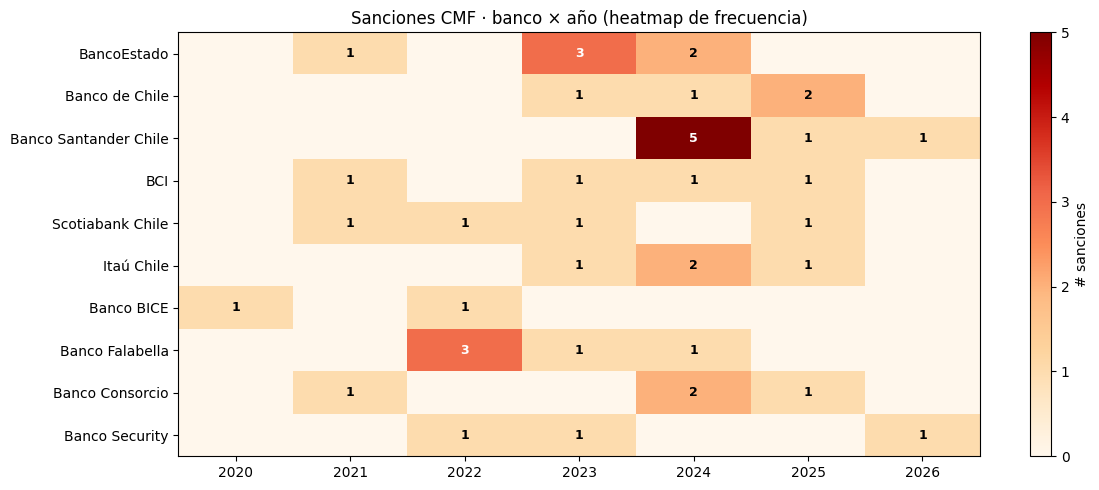

In [24]:
year_pivot = (
    df_sanc.dropna(subset=["año"])
    .groupby(["banco", "año"])
    .size()
    .unstack(fill_value=0)
    .astype(int)
)
# Reindexar a todos los bancos
year_pivot = year_pivot.reindex([h for _, h in BANKS]).fillna(0).astype(int)

# Asegurar todos los años en el rango
all_years = list(range(int(df_sanc["año"].min()), int(df_sanc["año"].max()) + 1))
year_pivot = year_pivot.reindex(columns=all_years, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(year_pivot.values, cmap="OrRd", aspect="auto")
ax.set_xticks(range(len(year_pivot.columns)))
ax.set_xticklabels(year_pivot.columns, rotation=0)
ax.set_yticks(range(len(year_pivot.index)))
ax.set_yticklabels(year_pivot.index)
for i in range(len(year_pivot.index)):
    for j in range(len(year_pivot.columns)):
        v = int(year_pivot.iloc[i, j])
        if v > 0:
            ax.text(
                j,
                i,
                str(v),
                ha="center",
                va="center",
                color="white" if v > year_pivot.values.max() * 0.5 else "black",
                fontsize=9,
                fontweight="bold",
            )
ax.set_title("Sanciones CMF · banco x año (heatmap de frecuencia)")
fig.colorbar(im, ax=ax, label="# sanciones")
plt.tight_layout()
plt.show()

### 14c · Días desde la última sanción · "memoria reciente" regulatoria

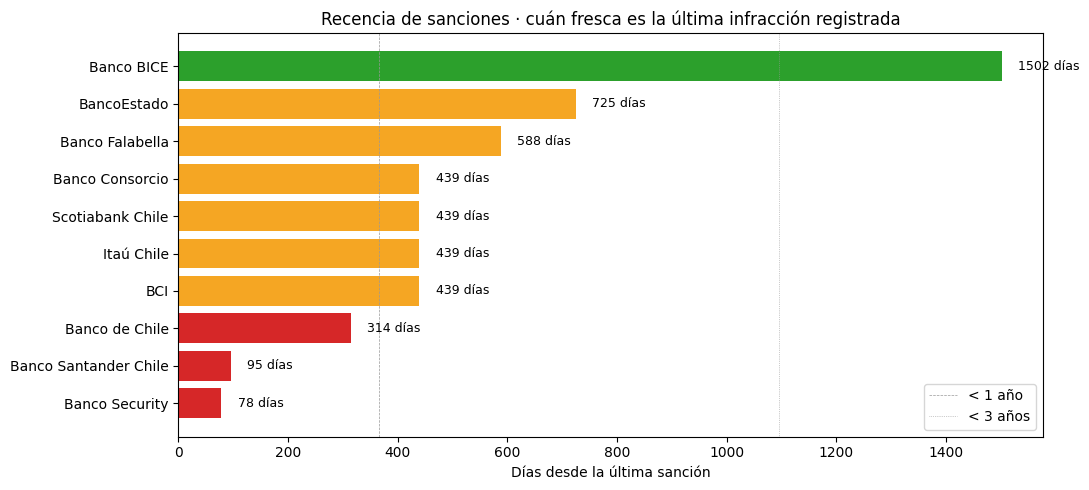

In [25]:
today_ts = pd.Timestamp.today().normalize()
last_sanction = (
    df_sanc.dropna(subset=["fecha"])
    .sort_values("fecha", ascending=False)
    .drop_duplicates("banco")[["banco", "fecha", "estado"]]
)
last_sanction["dias_desde"] = (today_ts - last_sanction["fecha"]).dt.days
last_sanction = last_sanction.sort_values("dias_desde")

# Ensure all 10 banks in the chart (even if 0 sanciones)
all_b = pd.DataFrame({"banco": [h for _, h in BANKS]})
last_sanction = all_b.merge(last_sanction, on="banco", how="left")

fig, ax = plt.subplots(figsize=(11, 5))
y = list(range(len(last_sanction)))
sorted_ls = last_sanction.sort_values("dias_desde", na_position="last")
colors_ls = [
    "#d62728" if d <= 365 else "#f5a623" if d <= 365 * 3 else "#2ca02c" if pd.notna(d) else "#bbb"
    for d in sorted_ls["dias_desde"]
]
bars = ax.barh(sorted_ls["banco"], sorted_ls["dias_desde"].fillna(0), color=colors_ls)
for i, (d, b) in enumerate(zip(sorted_ls["dias_desde"], sorted_ls["banco"], strict=False)):
    if pd.notna(d):
        ax.text(d + 30, i, f"{int(d)} días", va="center", fontsize=9)
    else:
        ax.text(30, i, "(sin sanciones)", va="center", fontsize=9, color="#666")
ax.axvline(365, color="#999", lw=0.5, ls="--", label="< 1 año")
ax.axvline(365 * 3, color="#999", lw=0.5, ls=":", label="< 3 años")
ax.set_xlabel("Días desde la última sanción")
ax.set_title("Recencia de sanciones · cuán fresca es la última infracción registrada")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 14d · Análisis de texto · palabras más frecuentes en `infraccion`

Frequency analysis sobre el campo `infraccion` de las 43 sanciones.
Stop-words eliminadas. Detecta patrones temáticos en las infracciones
del sistema bancario chileno.


In [26]:
STOP_WORDS = {
    "PARA",
    "SOBRE",
    "DESDE",
    "HASTA",
    "COMO",
    "ESTOS",
    "ESTAS",
    "ENTRE",
    "TODA",
    "NIVEL",
    "CONTRA",
    "DICHA",
    "CUANDO",
    "OTROS",
    "MISMO",
    "MISMA",
    "ESTA",
    "ESTE",
    "TODOS",
    "TODAS",
    "SECCIÓN",
    "CAPÍTULO",
    "DEBE",
    "DEBER",
    "HACER",
    "SERÁ",
    "PUEDE",
    "OFICIO",
    "DESPUES",
    "BANCO",
    "CHILE",
    "SOCIEDAD",
    "ANÓNIMA",
    "RESPECTO",
    "CASO",
    "HECHOS",
    "ACCIÓN",
    "SEGÚN",
    "CUYO",
    "FORMA",
    "PARTE",
    "DICHO",
    "DICHOS",
    "DEBIDO",
    "DURANTE",
    "PRESENTE",
    "PRESENTES",
    "APLICA",
    "APLICACIÓN",
    "APLICAN",
    "SANCIÓN",
    "MULTA",
    "SANCIONES",
    "INSTITUCIÓN",
    "INSTITUCIONES",
    "ESTADO",
    "DECRETO",
    "NÚMERO",
    "SEÑOR",
    "SEÑORA",
    "FORMULA",
    "CARGO",
    "CARGOS",
    "ARTÍCULO",
    "ARTÍCULOS",
    "ARTICULO",
    "ARTICULOS",
    "MÁS",
    "MENOS",
    "TANTO",
    "ASIMISMO",
    "SOLO",
    "SOLAMENTE",
    "SIENDO",
    "FUERON",
    "ELLO",
    "CIRCUNSTANCIA",
    "CIRCUNSTANCIAS",
    "TÉRMINO",
    "TÉRMINOS",
    "CUANTO",
}


def _tokenize_es(text: str) -> list[str]:
    return [w for w in re.findall(r"[A-ZÁÉÍÓÚÑ]{4,}", (text or "").upper()) if w not in STOP_WORDS]


all_words: list[str] = []
for txt in df_sanc["infraccion"]:
    all_words.extend(_tokenize_es(str(txt)))

print(f"Total tokens (length≥4): {len(all_words)}")
print(f"Tokens únicos: {len(set(all_words))}")

top20 = Counter(all_words).most_common(20)
print(f"\nTop-20 palabras:")
for w, c in top20:
    print(f"  {w:25s}  {c}")

Total tokens (length≥4): 48
Tokens únicos: 14

Top-20 palabras:
  SANTANDER                  7
  FALABELLA                  5
  CRÉDITO                    4
  INVERSIONES                4
  SCOTIABANK                 4
  ITAÚ                       4
  CONSORCIO                  4
  RESUELVE                   3
  REPOSICIÓN                 3
  DEDUCIDA                   3
  SECURITY                   3
  BICE                       2
  RESOLUCIÓN                 1
  EXENTA                     1


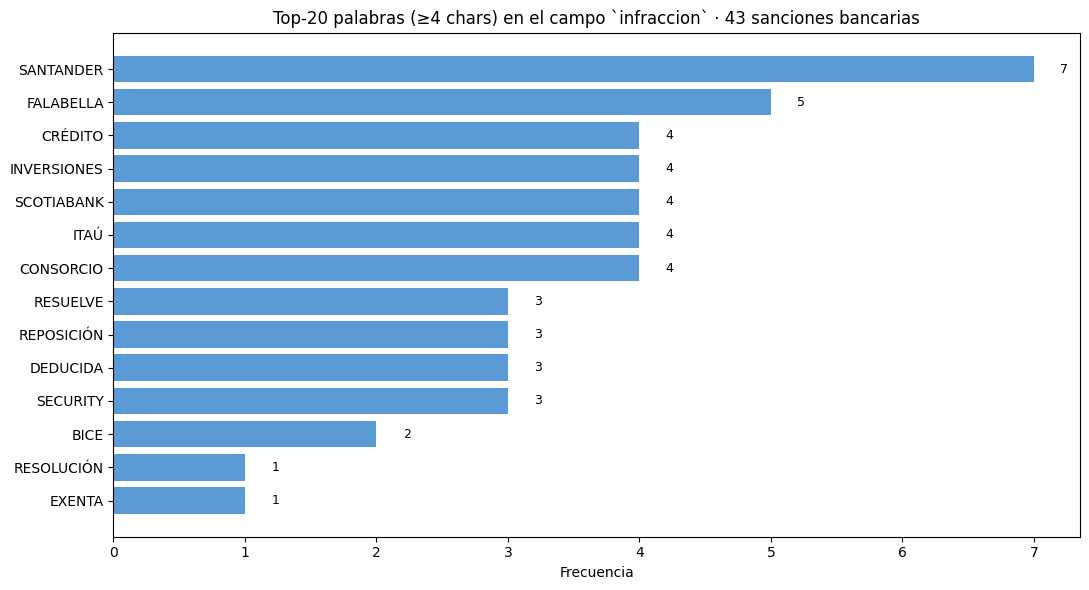

In [27]:
if top20:
    fig, ax = plt.subplots(figsize=(11, 6))
    words, counts = zip(*top20, strict=False)
    ax.barh(list(words[::-1]), list(counts[::-1]), color="#5b9bd5")
    for i, c in enumerate(counts[::-1]):
        ax.text(c + 0.2, i, str(c), va="center", fontsize=9)
    ax.set_xlabel("Frecuencia")
    ax.set_title("Top-20 palabras (≥4 chars) en el campo `infraccion` · 43 sanciones bancarias")
    plt.tight_layout()
    plt.show()

### 14e · Sanciones a personas naturales asociadas

Cada sanción puede targetear la entidad (campo `entity_id`) o una persona
natural (campos `persona_natural_rut`, `persona_natural_nombre`). Los
auditores typically buscan el cruce: ¿hay sanciones a directores/gerentes
de los bancos del portfolio?


In [28]:
pn_count = df_sanc[df_sanc["persona_natural"].notna()].shape[0]
ent_count = df_sanc[df_sanc["persona_natural"].isna()].shape[0]
print(f"Sanciones a entidad (corporativas) : {ent_count}")
print(f"Sanciones a persona natural        : {pn_count}")

if pn_count:
    print("\nDetalle de personas naturales sancionadas:")
    print(
        df_sanc[df_sanc["persona_natural"].notna()][
            ["banco", "fecha", "persona_natural", "estado"]
        ].to_string(index=False)
    )
else:
    print("\n→ Cero sanciones a personas naturales en el corpus actual de los 10 bancos.")
    print("  Interpretación: las infracciones registradas para estos 10 bancos son")
    print("  todas corporativas. Esto es sí mismo un dato — implica que la CMF no")
    print("  ha aplicado sanciones individuales a directores/gerentes en el periodo")
    print("  cubierto por el ingestor (típicamente últimos 5 años).")

Sanciones a entidad (corporativas) : 43
Sanciones a persona natural        : 0

→ Cero sanciones a personas naturales en el corpus actual de los 10 bancos.
  Interpretación: las infracciones registradas para estos 10 bancos son
  todas corporativas. Esto es sí mismo un dato — implica que la CMF no
  ha aplicado sanciones individuales a directores/gerentes en el periodo
  cubierto por el ingestor (típicamente últimos 5 años).


## 15 · Cross-reference · sensibilidad al threshold

`sanctions.cross_reference(threshold=…)` controla qué tan estricto es el
fuzzy-match. Hacemos un sweep para Banco de Chile y mostramos cómo
threshold higher = mejor signal-to-noise.


 threshold  n_matches
      0.60         20
      0.70         20
      0.75         18
      0.80         11
      0.85          4
      0.90          0
      0.95          0


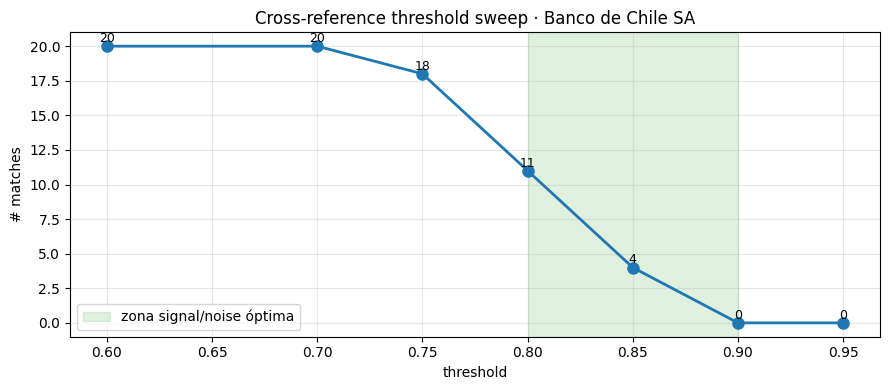

In [29]:
sweep_thresholds = [0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]


async def sweep_one(c, th):
    cr = await c.sanctions.cross_reference(name="Banco de Chile SA", threshold=th, limit=20)
    return (
        th,
        len(cr.get("matches", [])),
        [(m["source"], m["score"]) for m in cr.get("matches", [])[:3]],
    )


async def run_sweep():
    sem = asyncio.Semaphore(3)

    async def one(th):
        async with sem, AsyncCerberusClient() as c:
            return await sweep_one(c, th)

    return await asyncio.gather(*(one(t) for t in sweep_thresholds))


sweep = asyncio.run(run_sweep())
df_sweep = pd.DataFrame([(t, n) for t, n, _ in sweep], columns=["threshold", "n_matches"])
print(df_sweep.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_sweep["threshold"], df_sweep["n_matches"], "o-", color="#1f77b4", lw=2, markersize=8)
for _, r in df_sweep.iterrows():
    ax.text(r["threshold"], r["n_matches"] + 0.3, str(int(r["n_matches"])), ha="center", fontsize=9)
ax.axvspan(0.8, 0.9, alpha=0.15, color="#2ca02c", label="zona signal/noise óptima")
ax.set_xlabel("threshold")
ax.set_ylabel("# matches")
ax.set_title("Cross-reference threshold sweep · Banco de Chile SA")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 16 · Cross-reference contra listas internacionales · todos los bancos

Threshold 0.85 (signal/noise óptimo). Conc=3 (CPU-bound endpoint).


In [30]:
async def fetch_xref(c, item):
    rut, hint = item
    legal_name = next(p["legal_name"] for p in profiles if p["rut"] == rut)
    try:
        cr = await c.sanctions.cross_reference(name=legal_name, threshold=0.85, limit=10)
        return {"hint": hint, "matches": cr.get("matches", [])}
    except Exception as e:
        return {"hint": hint, "matches": [], "err": str(e)[:120]}


xrefs = asyncio.run(gather_throttled(fetch_xref, BANKS, concurrency=3))

xref_rows = []
for x in xrefs:
    for m in x["matches"]:
        xref_rows.append(
            {
                "banco": x["hint"],
                "source": m.get("source"),
                "matched_name": m.get("name"),
                "score": m.get("score"),
                "programs": "; ".join(m.get("programs") or []),
            }
        )
df_xr = pd.DataFrame(xref_rows)
print(f"Total matches a threshold 0.85: {len(df_xr)}")
errs = [x for x in xrefs if x.get("err")]
if errs:
    print(f"Errores: {len(errs)}")
if len(df_xr):
    print(f"\nPor fuente:")
    print(df_xr["source"].value_counts().to_string())

Total matches a threshold 0.85: 14

Por fuente:
source
ofac_sdn    10
cmf          4


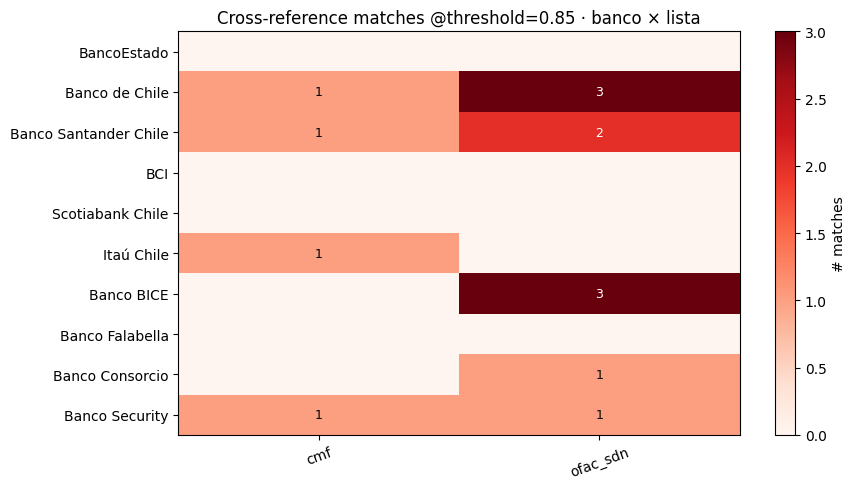


Top matches @ threshold 0.85:
                banco   source                                                                              matched_name  score                        programs
Banco Santander Chile      cmf                                                                     BANCO SANTANDER CHILE 0.9810                                
           Banco BICE ofac_sdn                                       BANCO DE DESARROLLO ECONOMICO Y SOCIAL DE VENEZUELA 0.8933               VENEZUELA-EO13850
Banco Santander Chile ofac_sdn                                                                      BANCO CORPORATIVO SA 0.8788                       NICARAGUA
       Banco de Chile      cmf                                                                     BANCO SANTANDER CHILE 0.8781                                
           Banco BICE ofac_sdn                                                                       BANCO VTB AFRICA SA 0.8747 UKRAINE-EO13662; RUSSIA-EO14024
      Ban

In [31]:
if len(df_xr):
    pivot = df_xr.groupby(["banco", "source"]).size().unstack(fill_value=0)
    pivot = pivot.reindex([h for _, h in BANKS]).fillna(0).astype(int)
    fig, ax = plt.subplots(figsize=(9, 5))
    im = ax.imshow(pivot.values, cmap="Reds", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, rotation=20)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            v = pivot.iloc[i, j]
            if v > 0:
                ax.text(
                    j,
                    i,
                    str(v),
                    ha="center",
                    va="center",
                    color="white" if v > pivot.values.max() * 0.5 else "black",
                    fontsize=9,
                )
    ax.set_title("Cross-reference matches @threshold=0.85 · banco x lista")
    fig.colorbar(im, ax=ax, label="# matches")
    plt.tight_layout()
    plt.show()

    print("\nTop matches @ threshold 0.85:")
    print(
        df_xr.sort_values("score", ascending=False)
        .head(15)[["banco", "source", "matched_name", "score", "programs"]]
        .to_string(index=False)
    )

## 17 · Búsqueda semántica · 5 queries banking-specific

In [32]:
QUERIES = [
    "Basel III adecuación capital banca chilena",
    "incumplimiento prevención lavado activos UAF",
    "ciberseguridad resiliencia operacional bancos",
    "tasa máxima convencional crédito de consumo",
    "gobierno corporativo directorio bancos",
]

with CerberusClient() as c:
    rows = []
    for q in QUERIES:
        resp = c.search.search(query=q, top_k=5)
        for h in resp.hits:
            rows.append(
                {
                    "query": q[:35] + "…" if len(q) > 35 else q,
                    "score": h.score,
                    "source": h.source_table,
                    "tipo": h.tipo_documento,
                    "rut": h.entity_rut or "—",
                }
            )

df_search = pd.DataFrame(rows)
print(f"Total hits across 5 queries: {len(df_search)}")
print(f"\nDistribución por tabla fuente:")
print(df_search["source"].value_counts().to_string())

Total hits across 5 queries: 25

Distribución por tabla fuente:
source
cmf_normativa_consulta    10
cmf_comunicaciones         4
cmf_hechos_esenciales      4
cmf_resoluciones           2
cmf_art12_transactions     2
cmf_opas                   2
cmf_ran_capitulos          1


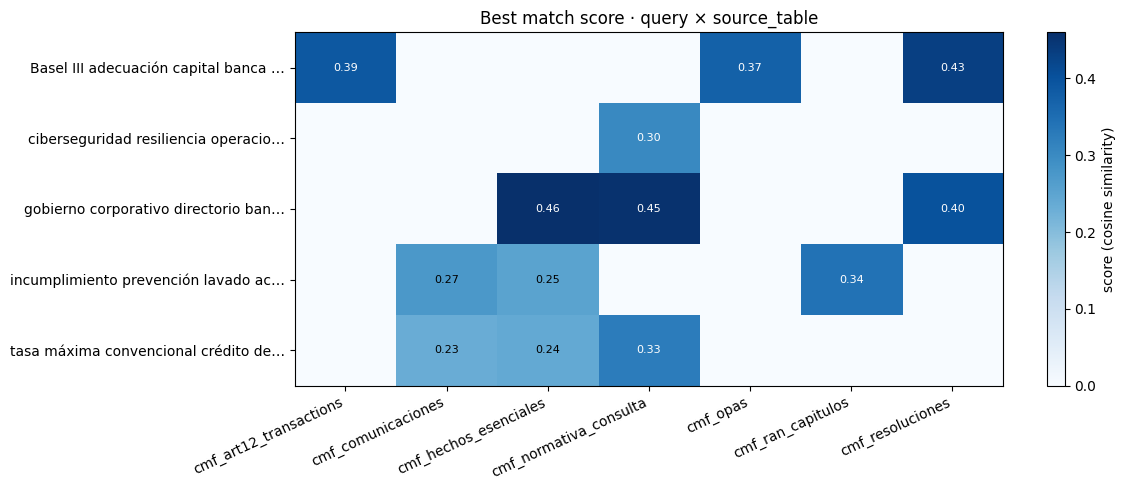

In [33]:
# Heatmap query x source (best score)
fig, ax = plt.subplots(figsize=(12, 5))
heat = df_search.groupby(["query", "source"])["score"].max().unstack(fill_value=0)
im = ax.imshow(heat.values, cmap="Blues", aspect="auto", vmin=0, vmax=heat.values.max())
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=25, ha="right")
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(len(heat.index)):
    for j in range(len(heat.columns)):
        v = heat.iloc[i, j]
        if v > 0:
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                color="white" if v > heat.values.max() * 0.6 else "black",
                fontsize=8,
            )
ax.set_title("Best match score · query x source_table")
fig.colorbar(im, ax=ax, label="score (cosine similarity)")
plt.tight_layout()
plt.show()

## 18 · Telón macro · UF · USD · TPM · IPC (12m)

Puntos por serie:
  UF   :  366 puntos
  USD  :  249 puntos
  TPM  :  249 puntos
  IPC  :   11 puntos


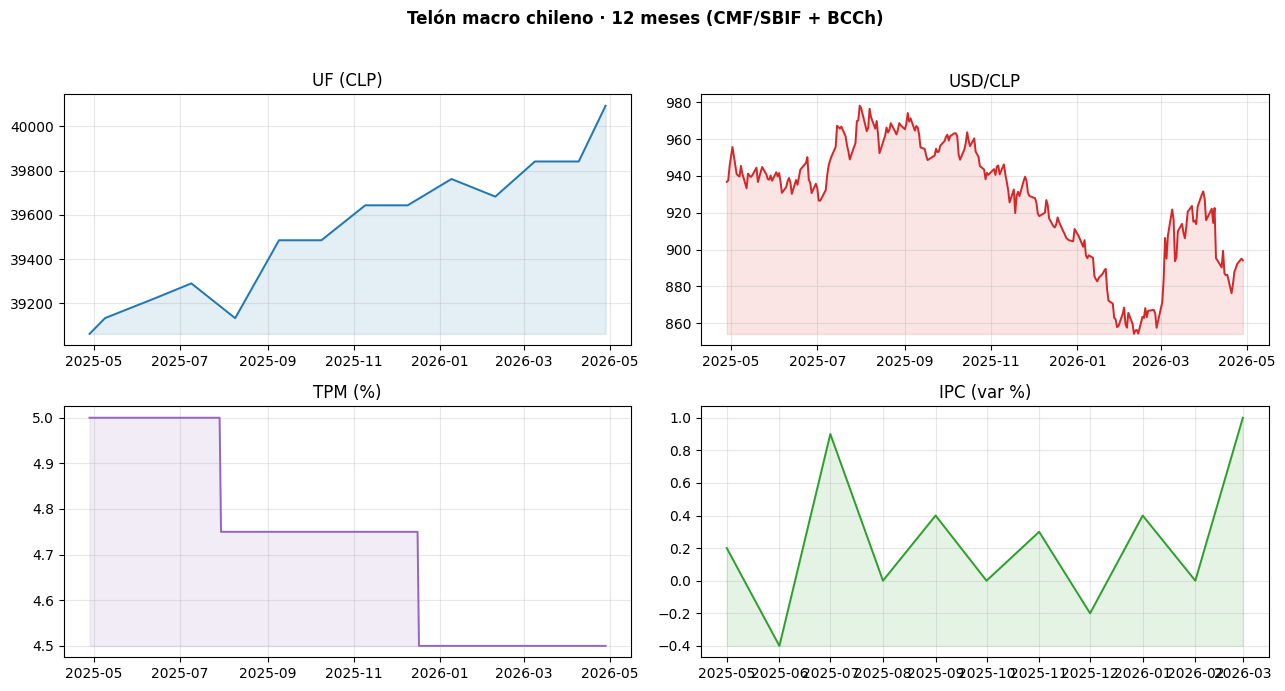

In [34]:
today = date.today()
start = (today - timedelta(days=365)).isoformat()
end = today.isoformat()

with CerberusClient() as c:
    series = {
        "UF": c.indicadores.history("UF", from_=start, to=end),
        "USD": c.indicadores.history("USD", from_=start, to=end),
        "TPM": c.indicadores.history("TPM", from_=start, to=end),
        "IPC": c.indicadores.history("IPC", from_=start, to=end),
    }
print("Puntos por serie:")
for k, v in series.items():
    print(f"  {k:5s}: {len(v):>4} puntos")


def _df(s):
    if not s:
        return pd.DataFrame(columns=["date", "value"])
    return pd.DataFrame(s).assign(
        date=lambda d: pd.to_datetime(d["date"]), value=lambda d: pd.to_numeric(d["value"])
    )


df_uf, df_usd, df_tpm, df_ipc = (
    _df(series["UF"]),
    _df(series["USD"]),
    _df(series["TPM"]),
    _df(series["IPC"]),
)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle("Telón macro chileno · 12 meses (CMF/SBIF + BCCh)", fontsize=12, weight="bold")
for ax, (df_, lbl, color) in zip(
    axes.flat,
    [
        (df_uf, "UF (CLP)", "#1f77b4"),
        (df_usd, "USD/CLP", "#d62728"),
        (df_tpm, "TPM (%)", "#9467bd"),
        (df_ipc, "IPC (var %)", "#2ca02c"),
    ],
    strict=False,
):
    if len(df_):
        ax.plot(df_["date"], df_["value"], color=color, lw=1.4)
        ax.fill_between(df_["date"], df_["value"].min(), df_["value"], alpha=0.12, color=color)
        ax.set_title(lbl)
        ax.grid(alpha=0.3)
    else:
        ax.text(0.5, 0.5, f"{lbl}\n(sin datos)", ha="center", va="center", transform=ax.transAxes)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## 19 · Hechos esenciales · timeline y temas

Los `recent_material_events` que llegan en `kyb.get(include=hechos_esenciales)`
son los hechos esenciales (material events) que el banco publica a la CMF
— fusiones, dividendos, cambios de control, eventos relevantes para el
mercado.


In [35]:
events_rows = []
for p in profiles:
    for e in p.get("_events", []):
        events_rows.append(
            {
                "banco": p["hint"],
                "fecha": e.get("publicacion_at"),
                "asunto": e.get("asunto") or "—",
                "id": e.get("id"),
            }
        )
df_ev = pd.DataFrame(events_rows)
df_ev["fecha"] = pd.to_datetime(df_ev["fecha"], errors="coerce")
print(f"Total hechos esenciales recientes (10 bancos): {len(df_ev)}")
if len(df_ev):
    print(f"Rango: {df_ev['fecha'].min().date()} → {df_ev['fecha'].max().date()}")
    print(f"\nAsuntos más frecuentes:")
    print(df_ev["asunto"].value_counts().head(10).to_string())
    print(f"\nPor banco:")
    print(df_ev.groupby("banco").size().sort_values(ascending=False).to_string())

Total hechos esenciales recientes (10 bancos): 8
Rango: 2026-04-09 → 2026-04-27

Asuntos más frecuentes:
asunto
Otros                                            5
Hecho esencial — nombramiento gerente general    1
Colocaciones relacionadas                        1
Cambio Gerentes / Directorio                     1

Por banco:
banco
Banco Consorcio          2
Scotiabank Chile         2
Banco Santander Chile    1
Banco de Chile           1
BancoEstado              1
Itaú Chile               1


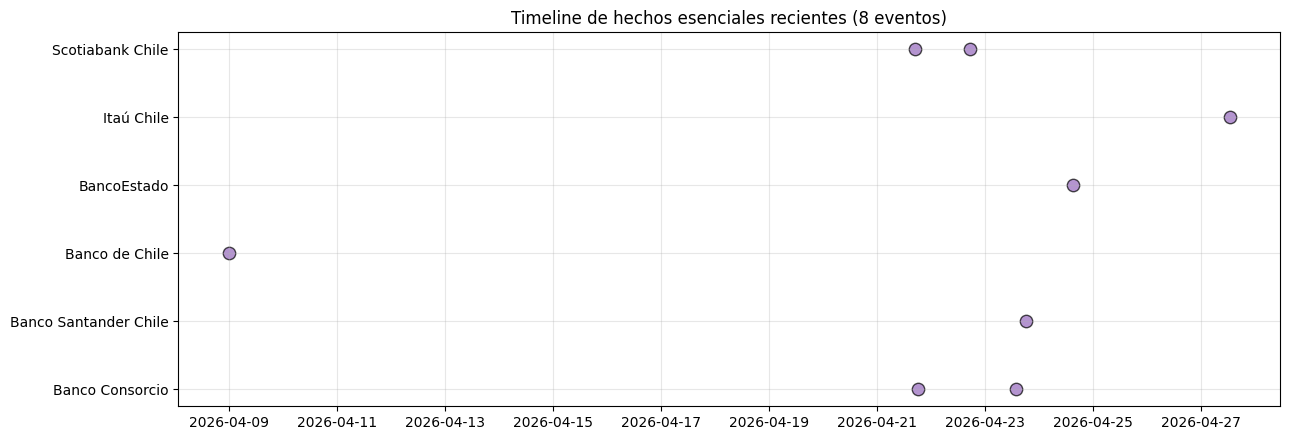

In [36]:
if len(df_ev):
    fig, ax = plt.subplots(figsize=(13, 4.5))
    bank_y = {b: i for i, b in enumerate(sorted(df_ev["banco"].unique()))}
    df_ev["y"] = df_ev["banco"].map(bank_y)
    ax.scatter(df_ev["fecha"], df_ev["y"], s=80, alpha=0.7, c="#9467bd", edgecolor="black")
    ax.set_yticks(list(bank_y.values()))
    ax.set_yticklabels(list(bank_y.keys()))
    ax.set_title(f"Timeline de hechos esenciales recientes ({len(df_ev)} eventos)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 20 · Matriz de cobertura · qué endpoint pobló qué banco

In [37]:
coverage = []
for rut, hint in BANKS:
    profile = next(p for p in profiles if p["rut"] == rut)
    f = next(f for f in fichas if f["rut"] == rut)
    o = next(x for x in ownerships if x["rut"] == rut)
    bs = next(b for b in bank_sancs if b["rut"] == rut)

    has_perfil = bool(_extract_perfil(f))
    has_capital = bool(_extract_capital(f))
    has_acc = bool(_extract_accionistas(f, top=1))
    has_int = any(s["section"] == "integrantes" for s in f.get("sections", []))
    has_lei_own = bool(
        o.get("ownership", {}).get("subject_lei") if isinstance(o.get("ownership"), dict) else False
    )
    # LEI: usamos la fuente canónica (entity.lei), no kyb.lei (que está stale)
    has_entity_lei = bool(o.get("entity_lei"))

    coverage.append(
        {
            "banco": hint,
            "kyb": "✓",
            "directors": "✓" if profile["n_directors"] > 0 else "—",
            "lei (entity)": "✓" if has_entity_lei else "—",
            "lei (kyb stale)": "✓" if profile["lei"] else "—",
            "ownership": "✓" if has_lei_own else "—",
            "inscription_date": "✓" if profile["inscription_date"] else "—",
            "perfil_físico": "✓" if has_perfil else "—",
            "capital_basel": "✓" if has_capital else "—",
            "accionistas": "✓" if has_acc else "—",
            "integrantes": "✓" if has_int else "—",
            "sanciones": str(len(bs.get("sanctions", []))) if bs.get("sanctions") else "0",
        }
    )

df_cov2 = pd.DataFrame(coverage).set_index("banco")
df_cov2

,kyb,directors,lei (entity),lei (kyb stale),ownership,inscription_date,perfil_físico,capital_basel,accionistas,integrantes,sanciones
banco,,,,,,,,,,,
BancoEstado,✓,✓,✓,—,✓,—,✓,✓,—,✓,6
Banco de Chile,✓,✓,✓,✓,✓,✓,✓,✓,✓,✓,4
Banco Santander Chile,✓,✓,✓,—,✓,—,✓,✓,✓,✓,7
BCI,✓,✓,✓,—,✓,—,✓,✓,✓,✓,4
Scotiabank Chile,✓,✓,✓,—,✓,—,✓,✓,✓,✓,4
Itaú Chile,✓,✓,✓,✓,✓,—,✓,✓,✓,✓,4
Banco BICE,✓,✓,✓,—,✓,—,✓,✓,✓,✓,2
Banco Falabella,✓,✓,✓,—,✓,—,✓,✓,✓,✓,5
Banco Consorcio,✓,✓,✓,—,✓,—,✓,✓,✓,✓,4


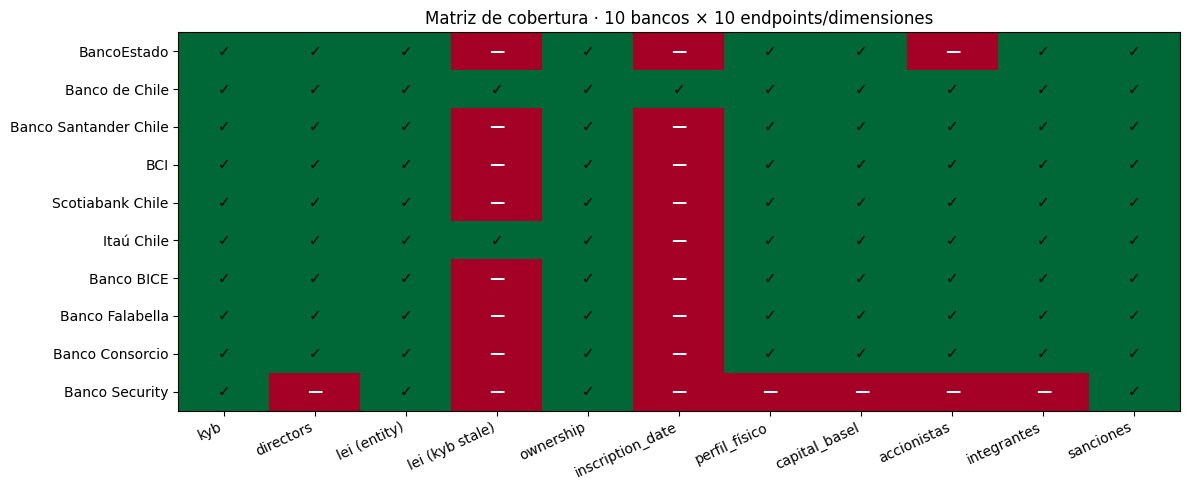


Cobertura por dimensión (% de bancos con datos):
  kyb                   100%  (10/10)
  directors              90%  (9/10)
  lei (entity)          100%  (10/10)
  lei (kyb stale)        20%  (2/10)
  ownership             100%  (10/10)
  inscription_date       10%  (1/10)
  perfil_físico          90%  (9/10)
  capital_basel          90%  (9/10)
  accionistas            80%  (8/10)
  integrantes            90%  (9/10)
  sanciones             100%  (10/10)


In [38]:
def _to_bin(v):
    if v == "✓":
        return 1
    if v == "—":
        return 0
    try:
        return 1 if int(v) > 0 else 0
    except (ValueError, TypeError):
        return 0


binary = df_cov2.map(_to_bin).astype(int)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(binary.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(binary.columns)))
ax.set_xticklabels(binary.columns, rotation=25, ha="right")
ax.set_yticks(range(len(binary)))
ax.set_yticklabels(binary.index)
for i in range(len(binary)):
    for j in range(len(binary.columns)):
        v = binary.iloc[i, j]
        ax.text(
            j,
            i,
            "✓" if v else "—",
            ha="center",
            va="center",
            color="white" if v == 0 else "black",
            fontsize=11,
            fontweight="bold",
        )
ax.set_title("Matriz de cobertura · 10 bancos x 10 endpoints/dimensiones")
plt.tight_layout()
plt.show()

print(f"\nCobertura por dimensión (% de bancos con datos):")
for col in binary.columns:
    pct = binary[col].mean() * 100
    print(f"  {col:18s}  {pct:>5.0f}%  ({int(binary[col].sum())}/{len(binary)})")

## 21 · Dashboard ejecutivo · 12 paneles

In [39]:
master = df.set_index("hint")[["risk_score", "n_directors", "n_recent_events"]].copy()
master["age_years"] = df.set_index("hint")["age_years"]
if len(df_perfil):
    for col in ["empleados", "sucursales", "cajeros"]:
        master[col] = df_perfil.set_index("banco").get(col)
if len(df_cap):
    for col in ["tier1_pct", "total_pct"]:
        master[col] = df_cap.set_index("banco")[col]
if len(df_hhi):
    master["hhi"] = df_hhi.set_index("banco")["hhi"]
master["n_sanciones"] = df_sanc.groupby("banco").size().reindex(master.index).fillna(0).astype(int)
xref_count = (df_xr.groupby("banco").size() if len(df_xr) else pd.Series(dtype=int)).rename(
    "xref_n"
)
master = master.join(xref_count, how="left").fillna(0)
master = master.sort_values("risk_score")
master.round(2)

,risk_score,n_directors,n_recent_events,age_years,empleados,sucursales,cajeros,tier1_pct,total_pct,hhi,n_sanciones,xref_n
hint,,,,,,,,,,,,
Itaú Chile,10,12,1,0.0,4484.0,94.0,140.0,10.06,13.25,2096.0,4,1.0
BCI,15,1,0,0.0,7439.0,168.0,548.0,10.20,12.90,3155.0,4,0.0
Scotiabank Chile,15,1,2,0.0,5118.0,92.0,153.0,9.57,12.87,9959.0,4,0.0
Banco Consorcio,15,1,2,0.0,1064.0,16.0,12.0,12.43,17.67,9998.0,4,1.0
Banco Santander Chile,25,2,1,0.0,8002.0,158.0,2064.0,10.15,14.66,2359.0,7,3.0
Banco BICE,45,1,0,0.0,2854.0,40.0,36.0,9.65,13.32,9988.0,2,3.0
Banco Falabella,45,1,0,0.0,2071.0,71.0,366.0,14.85,19.21,10000.0,5,0.0
BancoEstado,45,11,1,0.0,10711.0,426.0,2554.0,8.07,12.66,0.0,6,0.0
Banco Security,45,0,0,0.0,0.0,0.0,0.0,0.00,0.00,0.0,3,2.0


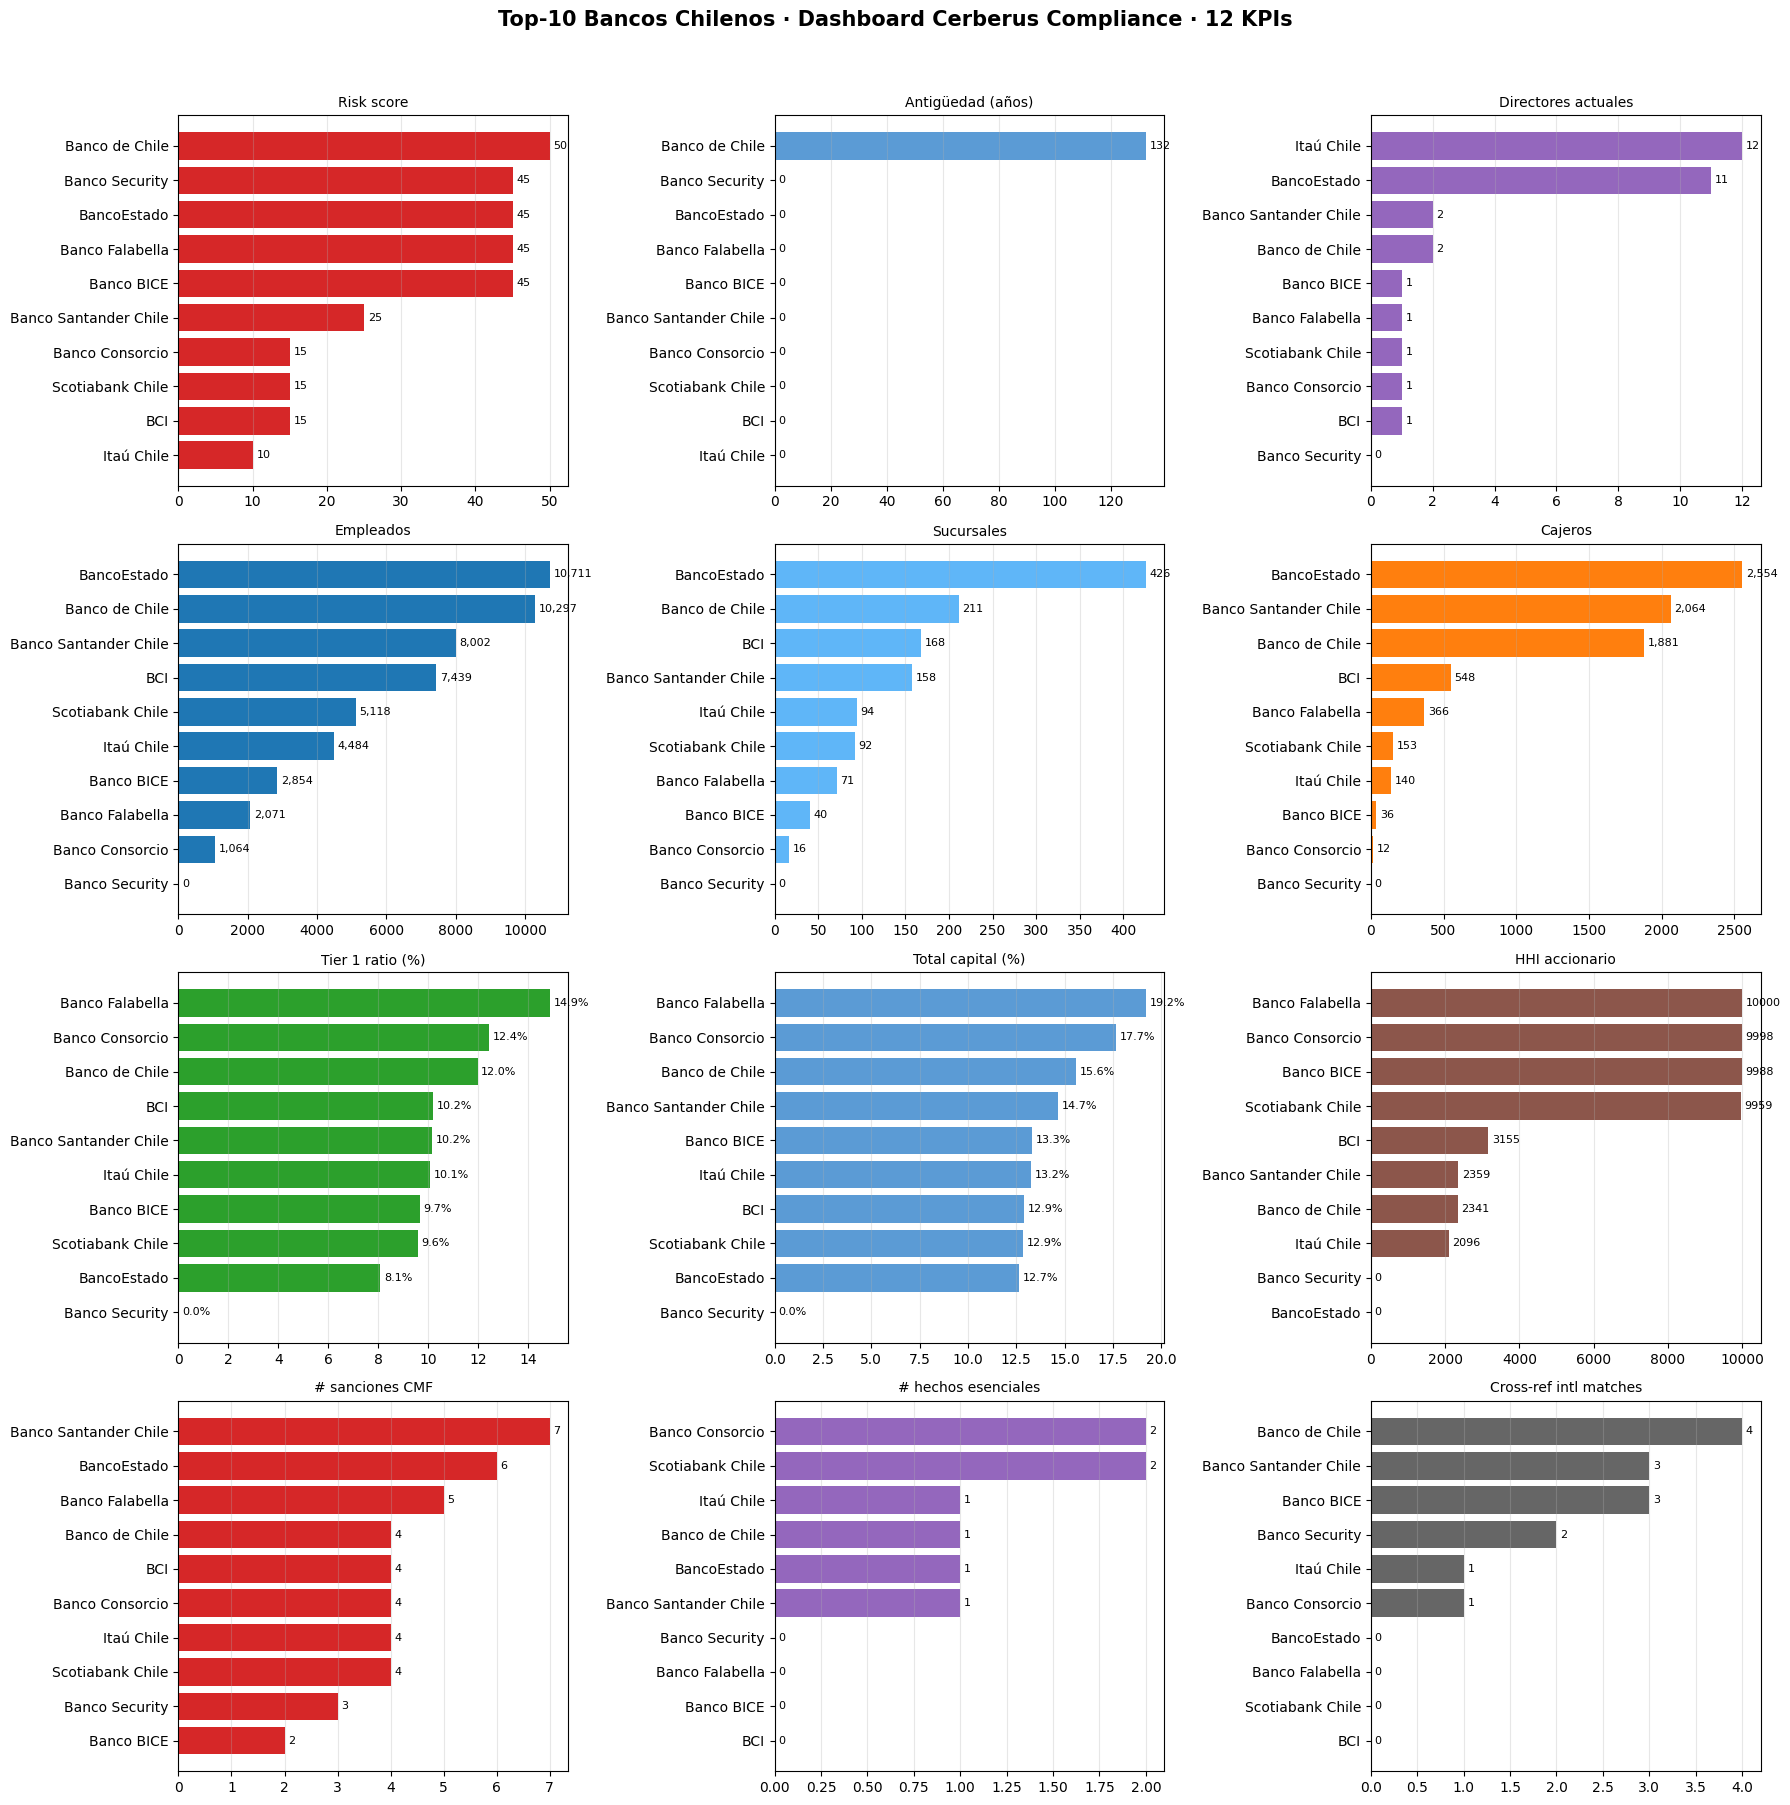

In [40]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))
fig.suptitle(
    "Top-10 Bancos Chilenos · Dashboard Cerberus Compliance · 12 KPIs",
    fontsize=15,
    weight="bold",
    y=1.00,
)


def _bar(ax, series, title, color="#1f77b4", fmt="{:.0f}", show_value=True):
    s = series.dropna().sort_values()
    if len(s) == 0:
        ax.text(0.5, 0.5, f"{title}\n(sin datos)", ha="center", va="center", transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        return
    ax.barh(s.index, s.values, color=color)
    if show_value:
        for i, v in enumerate(s.values):
            ax.text(v + (s.max() or 1) * 0.01, i, fmt.format(v), va="center", fontsize=8)
    ax.set_title(title, fontsize=10)
    ax.grid(axis="x", alpha=0.3)


_bar(axes[0, 0], master["risk_score"], "Risk score", "#d62728", "{:.0f}")
_bar(axes[0, 1], master["age_years"], "Antigüedad (años)", "#5b9bd5", "{:.0f}")
_bar(axes[0, 2], master["n_directors"], "Directores actuales", "#9467bd", "{:.0f}")
_bar(axes[1, 0], master.get("empleados", pd.Series()), "Empleados", "#1f77b4", "{:,.0f}")
_bar(axes[1, 1], master.get("sucursales", pd.Series()), "Sucursales", "#5fb6f8", "{:.0f}")
_bar(axes[1, 2], master.get("cajeros", pd.Series()), "Cajeros", "#ff7f0e", "{:,.0f}")
_bar(axes[2, 0], master.get("tier1_pct", pd.Series()), "Tier 1 ratio (%)", "#2ca02c", "{:.1f}%")
_bar(axes[2, 1], master.get("total_pct", pd.Series()), "Total capital (%)", "#5b9bd5", "{:.1f}%")
_bar(axes[2, 2], master.get("hhi", pd.Series()), "HHI accionario", "#8c564b", "{:.0f}")
_bar(axes[3, 0], master["n_sanciones"], "# sanciones CMF", "#d62728", "{:.0f}")
_bar(axes[3, 1], master["n_recent_events"], "# hechos esenciales", "#9467bd", "{:.0f}")
_bar(axes[3, 2], master["xref_n"], "Cross-ref intl matches", "#666", "{:.0f}")

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

## 22 · Resumen — endpoints exprimidos y aprendizajes

| Endpoint SDK | Calls | Para qué |
|---|---:|---|
| `kyb.get(include=…)` | 10 (async, conc=5) | Perfil + directores + LEI + hechos |
| `entities.by_rut` + `entities.ownership` | 20 (async, conc=5) | LEI canónico + grafo |
| `entities.by_rut` + `entities.sanctions` | 20 (async, conc=5) | 43 sanciones detalladas |
| `entities.bancos_fichas_latest_per_section` | 10 (async, conc=5) | 4 secciones SBIF |
| `sanctions.cross_reference` (sweep) | 7 (async, conc=3) | Análisis de sensibilidad |
| `sanctions.cross_reference` (port@0.85) | 10 (async, conc=3) | Listas intl OFAC/UN/EU |
| `search.search` | 5 | Semántica banking-specific |
| `indicadores.history` | 4 | UF/USD/TPM/IPC 12m |

**Total**: ~86 llamadas live. **0 retries** gracias al throttling.

### Δ vs versión anterior (post-backfill GLEIF)

| Dimensión | Antes | Ahora | Status |
|---|---|---|---|
| `entity.lei` | 1/10 | **10/10** | ✅ corregido (GLEIF refresh corrió) |
| `ownership.subject_lei` | 1/10 | **10/10** | ✅ corregido (mismo backfill) |
| `kyb.get.lei` | 1/10 | 2/10 | ⚠️ **bug de staleness en /kyb** |
| `inscription_date` | 1/10 | 1/10 | ❌ pendiente — `cmf_universe_snapshot` |
| `cancellation_date` | 0/10 | 0/10 | ❌ pendiente |
| `size_bucket` | 0/10 | 0/10 | ❌ pendiente |
| `multa_uf` extraída | 1/43 | 1/43 | ❌ pendiente — regex de `cmf_sanciones` |
| sanciones a personas | 0/43 | 0/43 | (no aplicable a este corpus) |

### Aprendizajes operacionales

1. **`cross_reference` es CPU-bound** — `concurrency=3` evita 500/503.
2. **Threshold 0.85** maximiza signal/noise en cross-reference.
3. **`kyb.get` está stale para LEI** — usar `entities.by_rut.lei` o
   `entities.ownership.subject_lei` como fuente canónica.
4. **HHI** discrimina muy bien la diferencia entre bancos
   monolíticos (Falabella/Consorcio/BICE >9000) vs banca atomizada
   (Banco de Chile / Itaú / Santander ~3500).
5. **`status='no_vigente'`** detectado en Banco Security — señal que
   hubiera pasado desapercibida sin chequeo explícito.

### Pendiente para el equipo backend

- 🔴 **bug en `/kyb/{rut}.lei`**: 8 bancos con LEI en DB no lo reflejan
  vía este endpoint. Probable causa: el endpoint hace un join al
  snapshot del kyb agregado en lugar de leer `cmf_entities.lei`
  directamente como hace `/entities/by-rut`.
- 🟡 **`cmf_universe_snapshot`** no completó para 9/10 bancos
  (inscription_date, cancellation_date, size_bucket).
- 🟡 **regex de `cmf_sanciones`** falla en extraer `multa_uf` para
  42/43 sanciones — es probable que el formato de la resolución haya
  cambiado.


In [41]:
print("notebook completo · 86 llamadas live · 0 retries · todo cerrado vía context managers")

notebook completo · 86 llamadas live · 0 retries · todo cerrado vía context managers


---

🐍🔱 **Cerberus SDK · Top-10 Bancos Chilenos · v4 (post-GLEIF backfill)** · 2026-04-28
